In [1]:
%load_ext autoreload

In [2]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

activity_col = "Activity_S3_1"

# 1. Obtain ortholog and NAC family tiles

In [3]:
ortholog_tile_activities = pd.read_csv("../data/sog1_orthologs_tile_activities.csv", index_col = 0)
ortholog_tile_activities

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,activ_err_end,name,tile_num,mid,Description_name,normalized_Activity_S3_1,norm_activity_2,motif_pos,len,adj_mid
0,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,NaN,B.rapa,1,21,BasicBrRa,0.031225,0.006882,146,445,-125
1,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,NaN,B.rapa,2,31,BasicBrRa,NaN,NaN,146,445,-115
2,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,NaN,B.rapa,3,41,BasicBrRa,0.108498,0.084155,146,445,-105
3,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,1190.094147,B.rapa,4,51,BasicBrRa,0.150475,0.126132,146,445,-95
4,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,NaN,B.rapa,5,61,BasicBrRa,0.065749,0.041406,146,445,-85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,2225.276406,Q6NQK2,38,391,BasicArTh,0.150821,0.126478,149,449,242
647,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,1226.659155,Q6NQK2,39,401,BasicArTh,0.111160,0.086817,149,449,252
648,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,3294.665302,Q6NQK2,40,411,BasicArTh,0.341908,0.317565,149,449,262
649,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,2585.293329,Q6NQK2,41,421,BasicArTh,0.258866,0.234523,149,449,272


Plan: create a weighted average of all activities measurements made over a certain tile

In [4]:
ortholog_tile_activities["range"] = [np.arange(s, e) for s, e in zip(ortholog_tile_activities["Start"], ortholog_tile_activities["End"])]
ortholog_tile_activities

,Start,End,Description,Other,tile,Unnamed: 0,Activity_S3_1,Error,BC Count,activ_err_start,...,name,tile_num,mid,Description_name,normalized_Activity_S3_1,norm_activity_2,motif_pos,len,adj_mid,range
0,1,41,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,4741.0,187.276143,NaN,1.0,NaN,...,B.rapa,1,21,BasicBrRa,0.031225,0.006882,146,445,-125,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
1,11,51,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,NaN,NaN,...,B.rapa,2,31,BasicBrRa,NaN,NaN,146,445,-115,"[11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 2..."
2,21,61,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,6219.0,650.731599,NaN,1.0,NaN,...,B.rapa,3,41,BasicBrRa,0.108498,0.084155,146,445,-105,"[21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 3..."
3,31,71,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,4954.0,902.494857,287.599290,4.0,614.895568,...,B.rapa,4,51,BasicBrRa,0.150475,0.126132,146,445,-95,"[31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 4..."
4,41,81,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,3090.0,394.336560,NaN,1.0,NaN,...,B.rapa,5,61,BasicBrRa,0.065749,0.041406,146,445,-85,"[41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 5..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
646,371,411,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,2924.0,904.569692,1320.706714,6.0,-416.137023,...,Q6NQK2,38,391,BasicArTh,0.150821,0.126478,149,449,242,"[371, 372, 373, 374, 375, 376, 377, 378, 379, ..."
647,381,421,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,6270.0,666.698396,559.960759,9.0,106.737637,...,Q6NQK2,39,401,BasicArTh,0.111160,0.086817,149,449,252,"[381, 382, 383, 384, 385, 386, 387, 388, 389, ..."
648,391,431,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,3263.0,2050.634351,1244.030950,9.0,806.603401,...,Q6NQK2,40,411,BasicArTh,0.341908,0.317565,149,449,262,"[391, 392, 393, 394, 395, 396, 397, 398, 399, ..."
649,401,441,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,712.0,1552.582733,1032.710596,9.0,519.872136,...,Q6NQK2,41,421,BasicArTh,0.258866,0.234523,149,449,272,"[401, 402, 403, 404, 405, 406, 407, 408, 409, ..."


In [5]:
ortholog_tile_activities_expanded = ortholog_tile_activities.explode("range").reset_index(drop = True)
relev_cols = ortholog_tile_activities_expanded[["name", "normalized_Activity_S3_1", "range", "mid", "adj_mid"]]
relev_cols["adj_range"] = relev_cols["range"] - (relev_cols["mid"] - relev_cols["adj_mid"])
relev_cols

,name,normalized_Activity_S3_1,range,mid,adj_mid,adj_range
0,B.rapa,0.031225,1,21,-125,-145
1,B.rapa,0.031225,2,21,-125,-144
2,B.rapa,0.031225,3,21,-125,-143
3,B.rapa,0.031225,4,21,-125,-142
4,B.rapa,0.031225,5,21,-125,-141
...,...,...,...,...,...,...
26035,Q6NQK2,0.350028,446,431,282,297
26036,Q6NQK2,0.350028,447,431,282,298
26037,Q6NQK2,0.350028,448,431,282,299
26038,Q6NQK2,0.350028,449,431,282,300


In [6]:
avg_activities = relev_cols.groupby(["name", "range"]).mean().reset_index()
avg_activities = avg_activities.reset_index(drop = True)
avg_activities

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range
0,Amborellatrichopoda,1,0.050786,21.0,-82.0,-102.0
1,Amborellatrichopoda,2,0.050786,21.0,-82.0,-101.0
2,Amborellatrichopoda,3,0.050786,21.0,-82.0,-100.0
3,Amborellatrichopoda,4,0.050786,21.0,-82.0,-99.0
4,Amborellatrichopoda,5,0.050786,21.0,-82.0,-98.0
...,...,...,...,...,...,...
6985,ZeaMays,416,0.527065,401.0,253.0,268.0
6986,ZeaMays,417,0.527065,401.0,253.0,269.0
6987,ZeaMays,418,0.527065,401.0,253.0,270.0
6988,ZeaMays,419,0.527065,401.0,253.0,271.0


In [7]:
avg_activities[avg_activities["name"] == "Q6NQK2"]

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range
5020,Q6NQK2,1,0.096416,21.0,-128.0,-148.0
5021,Q6NQK2,2,0.096416,21.0,-128.0,-147.0
5022,Q6NQK2,3,0.096416,21.0,-128.0,-146.0
5023,Q6NQK2,4,0.096416,21.0,-128.0,-145.0
5024,Q6NQK2,5,0.096416,21.0,-128.0,-144.0
...,...,...,...,...,...,...
5465,Q6NQK2,446,0.350028,431.0,282.0,297.0
5466,Q6NQK2,447,0.350028,431.0,282.0,298.0
5467,Q6NQK2,448,0.350028,431.0,282.0,299.0
5468,Q6NQK2,449,0.350028,431.0,282.0,300.0


In [8]:
avg_activities["name"].value_counts()

name
MarchantiaPolymorpha                    530
Nelumbonucifera                         500
B.distachyon                            490
PhyscomitriumPatens                     490
S.bicolor                               490
B.rapa                                  450
Q6NQK2                                  450
Nicotianatabacum(tobacco)               440
E.grandis                               430
G.max                                   430
PopulusTrichocarpa                      430
V.vinifera peptide                      430
OryzaSativa                             420
ZeaMays                                 420
Amborellatrichopoda                     410
Selaginellamoellendorffii(spikemoss)    180
Name: count, dtype: int64

What do the averaged traces look like vs the original?

In [9]:
from scipy.ndimage import gaussian_filter1d

def plot_traces(name):
    fig, axs = plt.subplots(3, 1, sharex = True, figsize = (5,4), dpi = 150)
    sns.lineplot(data = ortholog_tile_activities_expanded[ortholog_tile_activities_expanded["name"] == name], x = "mid", y = "normalized_Activity_S3_1", ax = axs[0], label = "Centered Tile")
    sns.lineplot(data = avg_activities[avg_activities["name"] == name], x = "range", y = "normalized_Activity_S3_1", ax = axs[1], label = "Average of Tiles")
    
    # Gaussian smoothing for the third line plot (Smoothed data)
    smoothed_data = gaussian_filter1d(
        avg_activities[avg_activities["name"] == name]["normalized_Activity_S3_1"], sigma=3  # Adjust 'sigma' for the smoothness
    )
    
    # Plot the smoothed data
    axs[2].plot(avg_activities[avg_activities["name"] == name]['range'], smoothed_data, 
                label = "Average of Tiles + Gaussian Smoothing")
    axs[2].legend()
    
    axs[1].set_xlabel("Position")
    axs[0].set_ylabel("")
    axs[1].set_ylabel("")
    
    fig.supylabel(activity_col, x = -0.01)
    plt.suptitle(name + " WT")
    sns.despine()

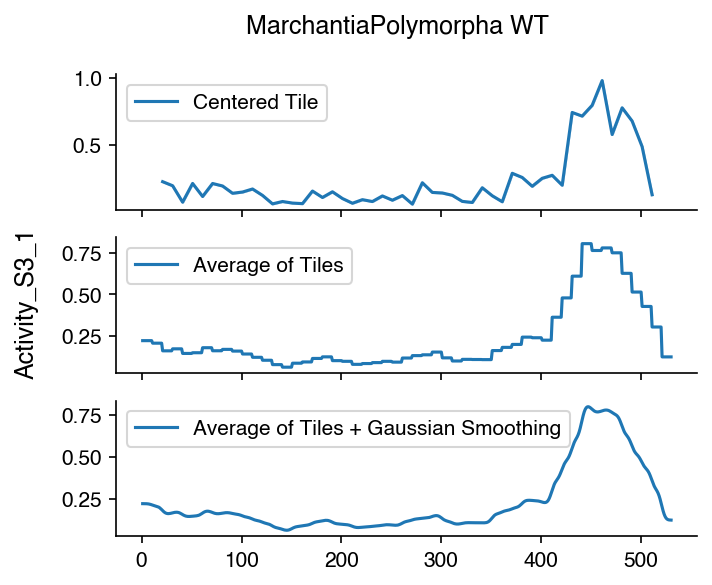

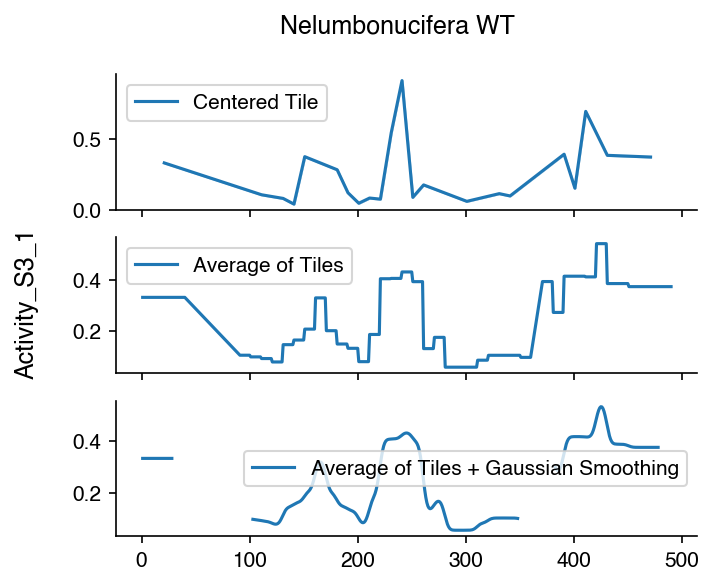

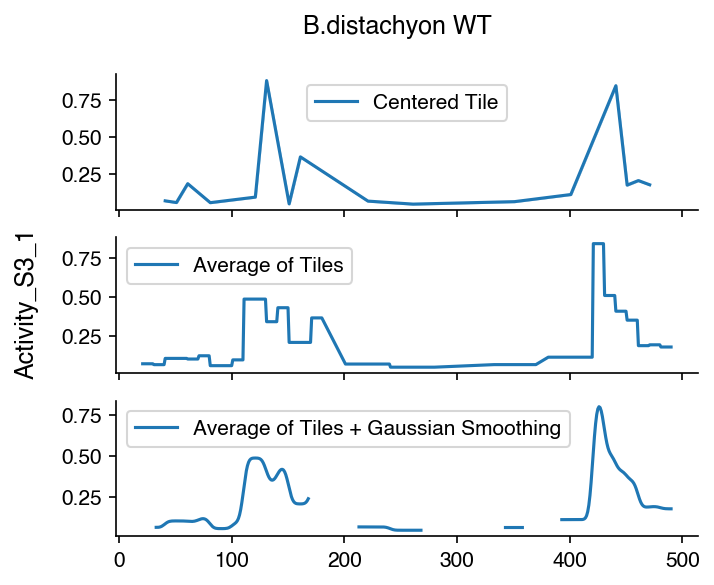

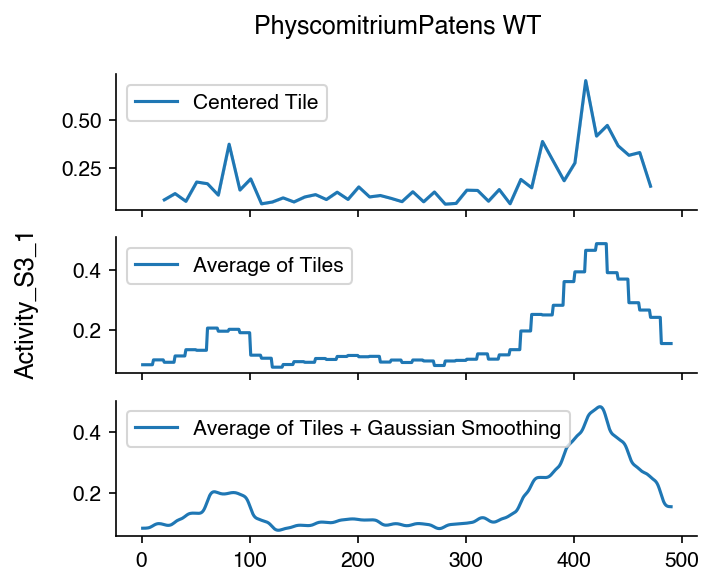

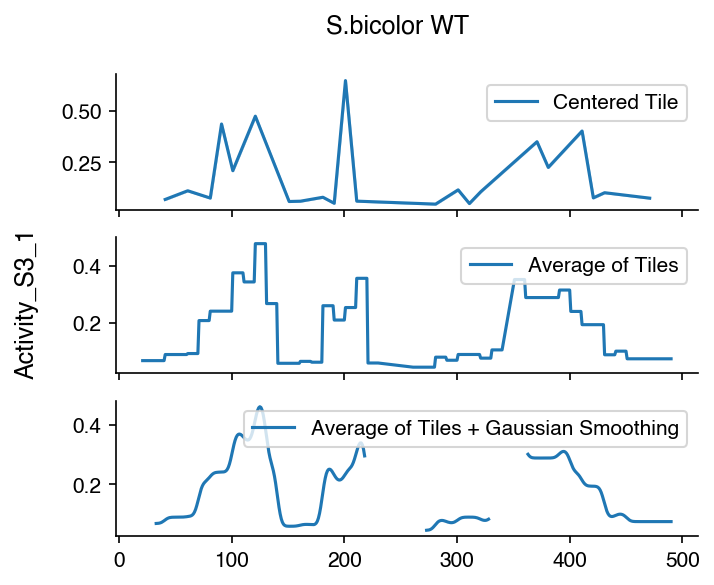

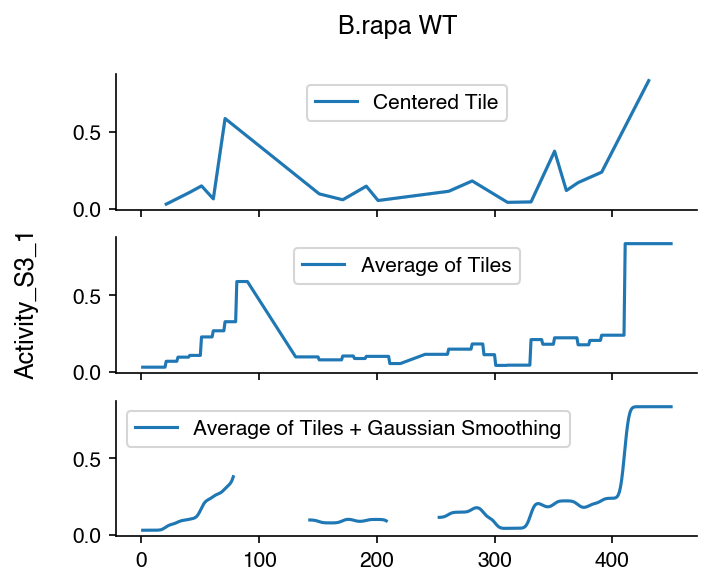

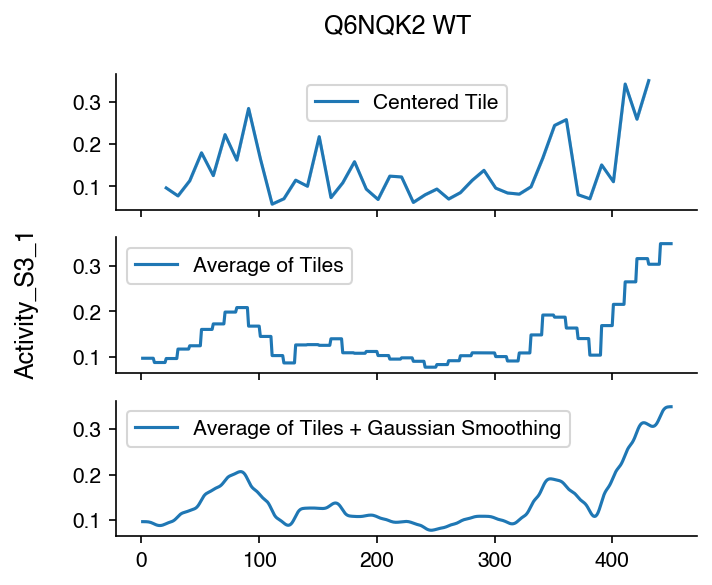

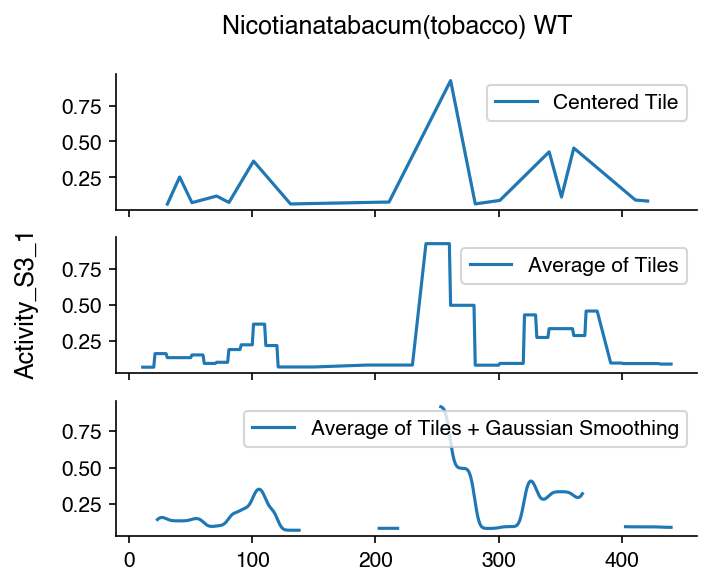

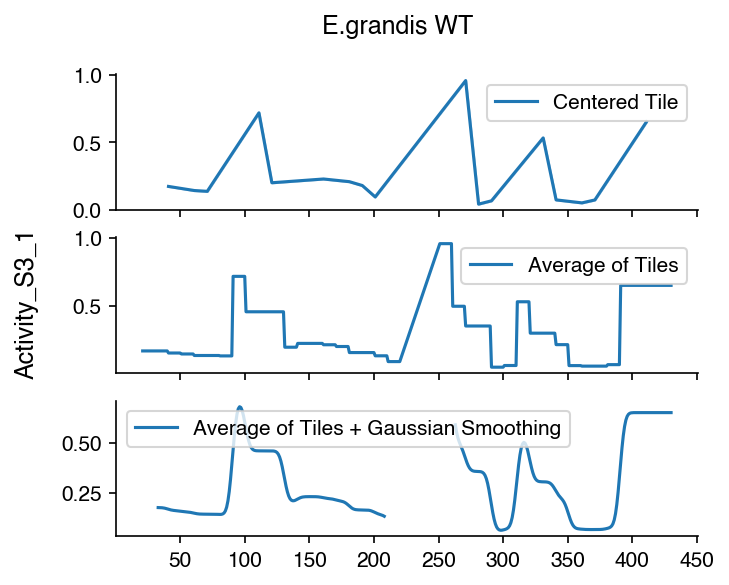

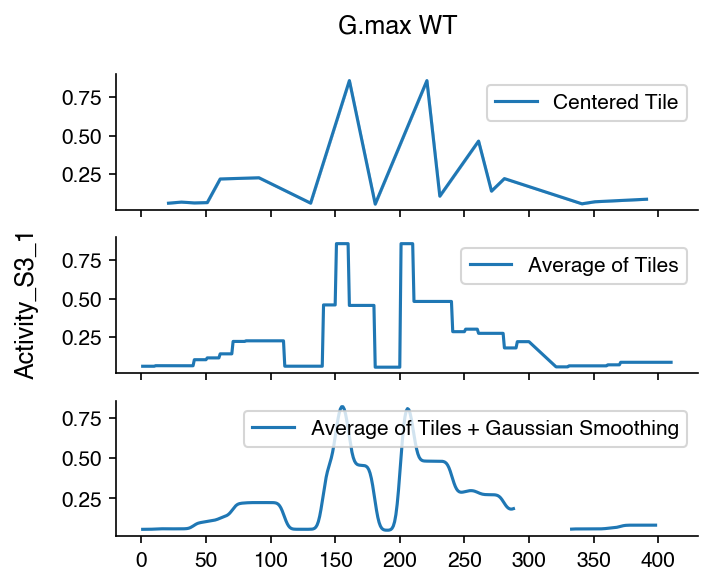

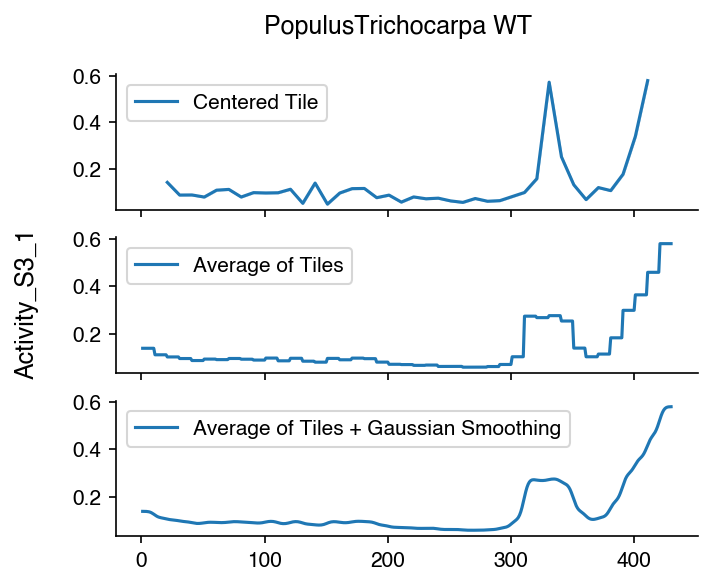

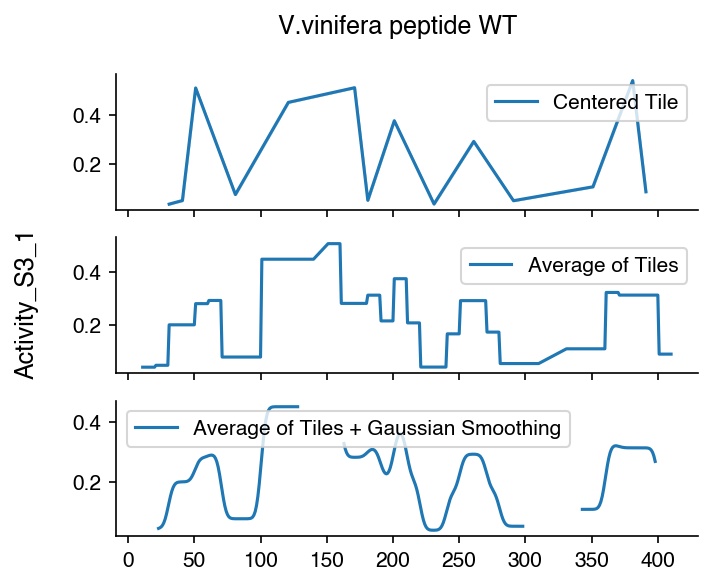

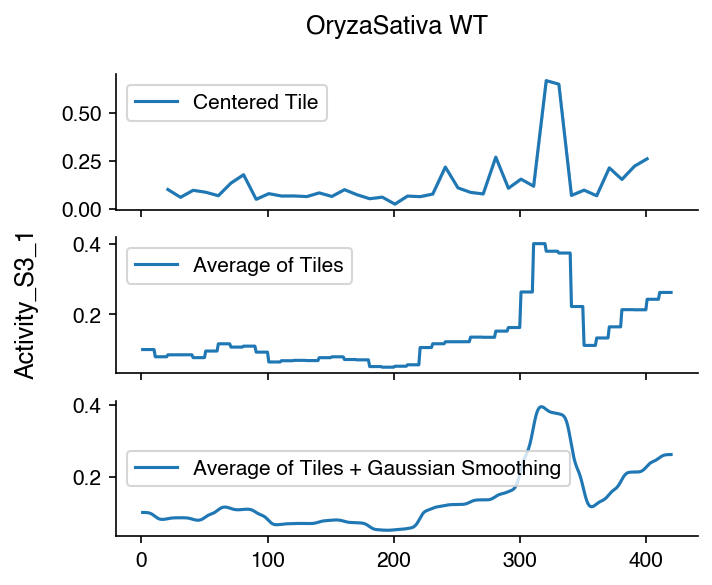

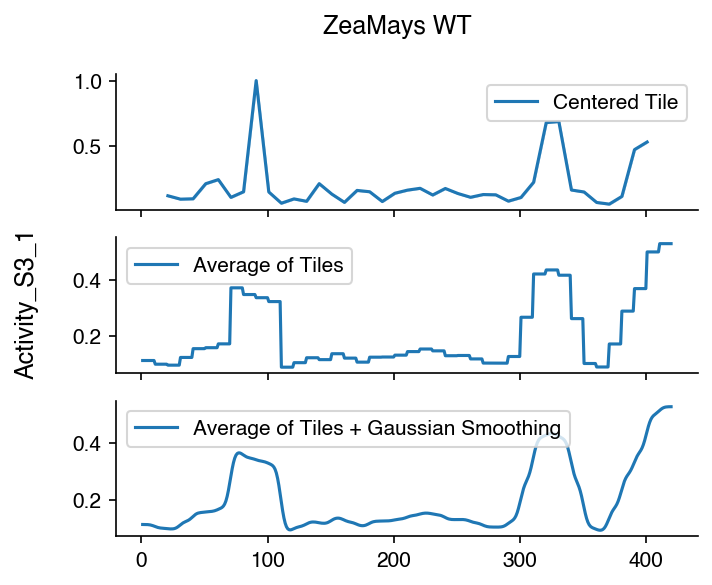

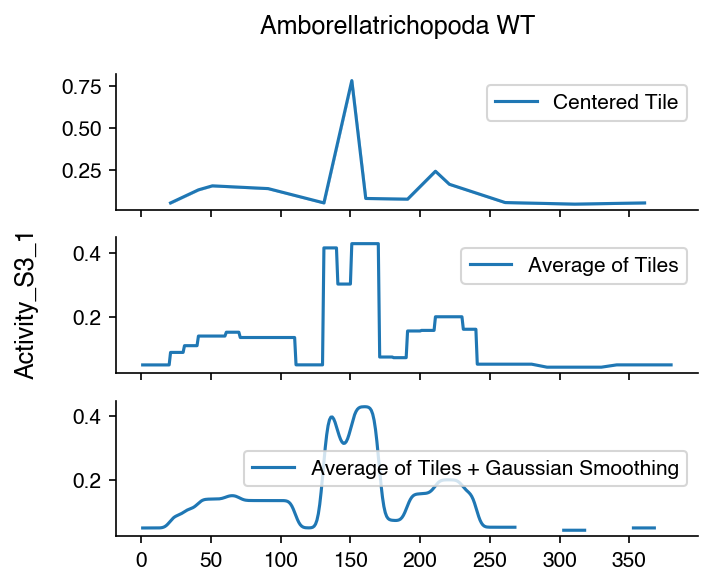

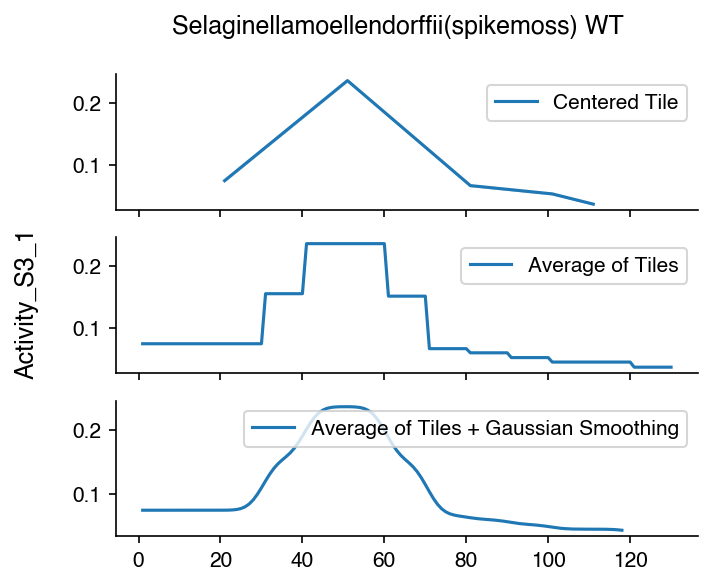

In [10]:
for name in avg_activities["name"].value_counts().index:
    plot_traces(name)

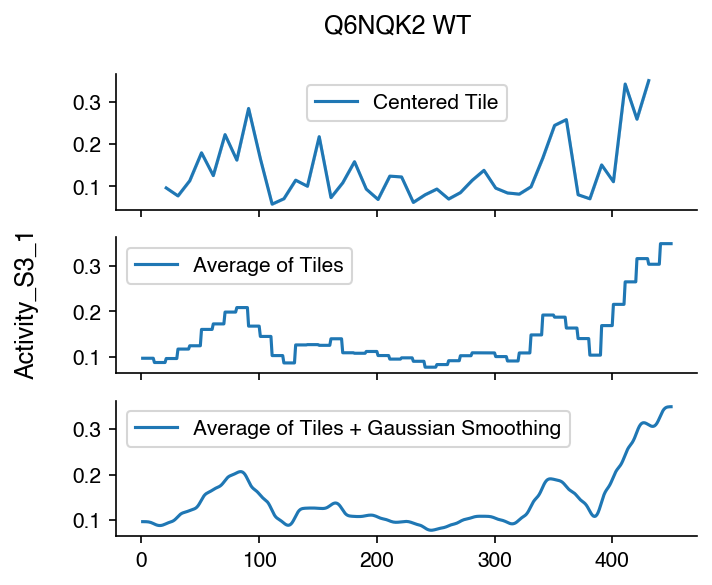

In [11]:
plot_traces("Q6NQK2")

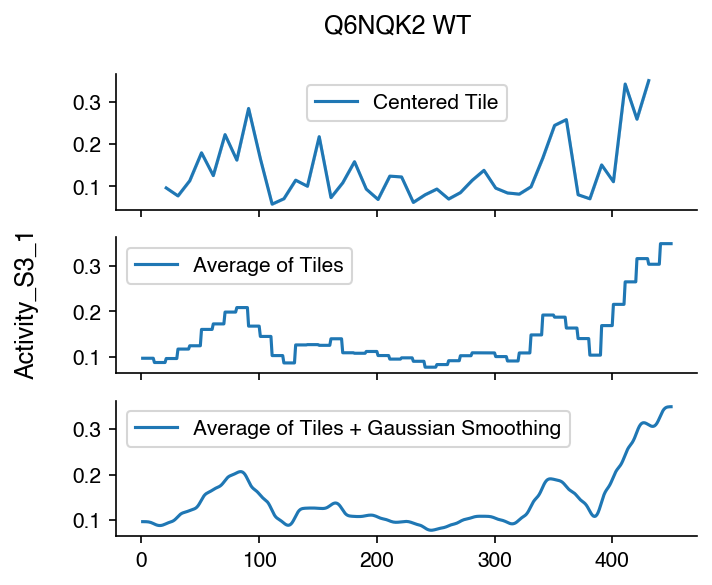

In [12]:
plot_traces("Q6NQK2")

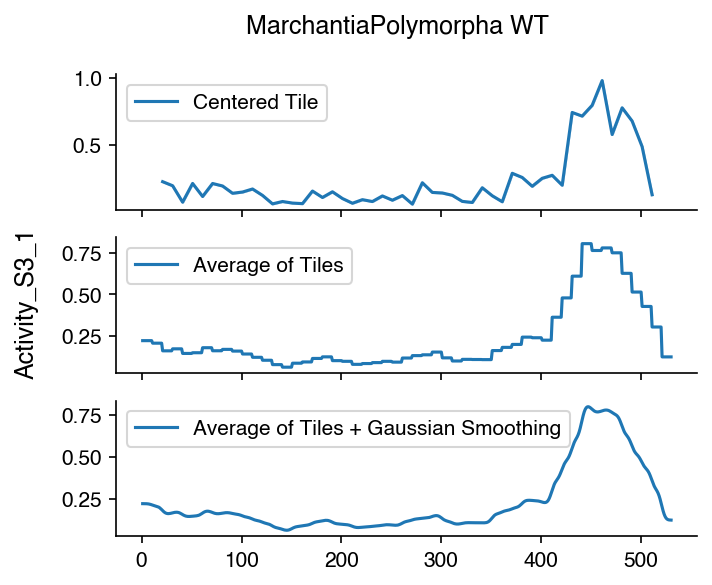

In [13]:
plot_traces("MarchantiaPolymorpha")

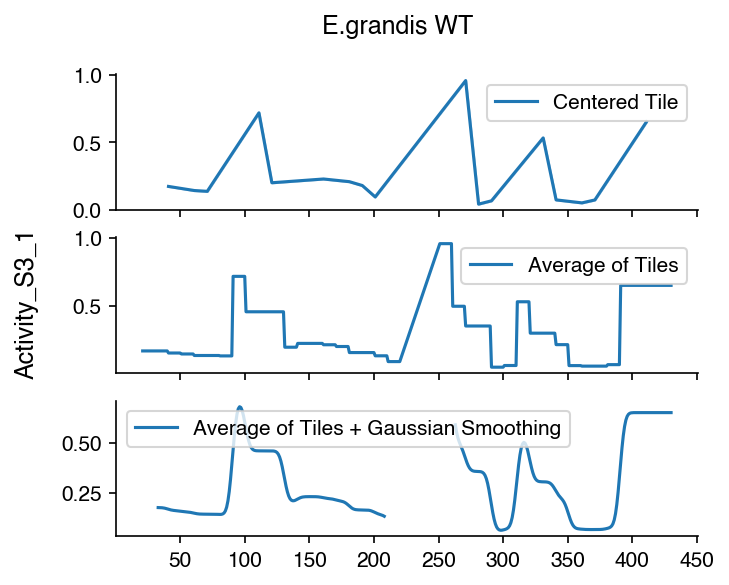

In [14]:
plot_traces("E.grandis")

--- 
Preparing data for alignment

In [15]:
sog1_orthologs = pd.read_csv("../data/sog1_orthologs.csv", sep = "\t")
sog1_orthologs["name"] = sog1_orthologs["Wild type sequences:"].str.split("_").str[0]
sog1_orthologs["name"] = sog1_orthologs["name"].str.replace("SOG1", "")
sog1_orthologs["name"] = sog1_orthologs["name"].str.strip()
ArTh_wt = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
sog1_orthologs.loc[15] = {"name" : "Q6NQK2", "Unnamed: 1" : ArTh_wt}
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [16]:
# Reading in the wt tiles of all sog1 orthologs and nac family tiles
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles = basic_tiles[~basic_tiles["Description"].str.contains("_")]
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
orthologs = basic_tiles[basic_tiles["name"].isin(sog1_orthologs["name"])]
orthologs["Description_name"] = orthologs["Description"].str.split(".").str[0]
other_to_descrip = orthologs[["Other", "Description_name"]].drop_duplicates()
other_to_descrip

,Other,Description_name
471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa
567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi
687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr
779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi
867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr
961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa
1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa
1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo
1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo
1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa


In [17]:
mapping = orthologs[["Description_name", "name"]].drop_duplicates()
mapping["name"] = mapping["name"].str.split(" ").str[0]
mapping_dict = dict(zip(mapping["Description_name"], mapping["name"]))
mapping_dict["BasicArTh"] = "A.thaliana"
mapping_dict["BasicPoTr"] = "P.trichocarpa"
mapping_dict["BasicNiTa"] = "N.tabacum"
mapping_dict["BasicSeMo"] = "S.moellendorffii"
mapping_dict["BasicMaPo"] = "M.polymorpha"
mapping_dict["BasicPhPa"] = "P.patens"
mapping_dict["BasicAmTr"] = "A.trichopoda"
mapping_dict["BasicOrSa"] = "O.sativa"
mapping_dict["BasicZeMa"] = "Z.mays"
mapping_dict["BasicNeSa"] = "N.nucifera"
other_to_descrip["standard_name"] = other_to_descrip["Description_name"].map(mapping_dict)
other_to_descrip

,Other,Description_name,standard_name
471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa
567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr,E.grandis
779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi,V.vinifera
867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr,P.trichocarpa
961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa,N.tabacum
1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa,G.max
1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo,S.moellendorffii
1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo,M.polymorpha
1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa,P.patens


In [18]:
other_to_descrip["name"] = other_to_descrip["Other"].str.split("_").str[0]
other_to_descrip["name"] = other_to_descrip["name"].str.replace("SOG1", "")
other_to_descrip["name"] = other_to_descrip["name"].str.strip().str.split(" ").str[0]
other_to_descrip

,Other,Description_name,standard_name,name
471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa
567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor,S.bicolor
687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr,E.grandis,E.grandis
779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi,V.vinifera,V.vinifera
867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr,P.trichocarpa,PopulusTrichocarpa
961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa,N.tabacum,Nicotianatabacum(tobacco)
1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa,G.max,G.max
1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo,S.moellendorffii,Selaginellamoellendorffii(spikemoss)
1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo,M.polymorpha,MarchantiaPolymorpha
1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa,P.patens,PhyscomitriumPatens


In [19]:
other_to_descrip.to_csv("../output/ortholog_name_mapping.csv")

In [20]:
avg_activities["name"].value_counts()

name
MarchantiaPolymorpha                    530
Nelumbonucifera                         500
B.distachyon                            490
PhyscomitriumPatens                     490
S.bicolor                               490
B.rapa                                  450
Q6NQK2                                  450
Nicotianatabacum(tobacco)               440
E.grandis                               430
G.max                                   430
PopulusTrichocarpa                      430
V.vinifera peptide                      430
OryzaSativa                             420
ZeaMays                                 420
Amborellatrichopoda                     410
Selaginellamoellendorffii(spikemoss)    180
Name: count, dtype: int64

In [21]:
avg_activities["name"] = avg_activities["name"].str.split(" ").str[0]
avg_activities

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range
0,Amborellatrichopoda,1,0.050786,21.0,-82.0,-102.0
1,Amborellatrichopoda,2,0.050786,21.0,-82.0,-101.0
2,Amborellatrichopoda,3,0.050786,21.0,-82.0,-100.0
3,Amborellatrichopoda,4,0.050786,21.0,-82.0,-99.0
4,Amborellatrichopoda,5,0.050786,21.0,-82.0,-98.0
...,...,...,...,...,...,...
6985,ZeaMays,416,0.527065,401.0,253.0,268.0
6986,ZeaMays,417,0.527065,401.0,253.0,269.0
6987,ZeaMays,418,0.527065,401.0,253.0,270.0
6988,ZeaMays,419,0.527065,401.0,253.0,271.0


In [22]:
avg_activities_with_std_names = pd.merge(avg_activities, other_to_descrip, 
         left_on = "name", right_on = "name", how = "left")
avg_activities_with_std_names

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range,Other,Description_name,standard_name
0,Amborellatrichopoda,1,0.050786,21.0,-82.0,-102.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
1,Amborellatrichopoda,2,0.050786,21.0,-82.0,-101.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
2,Amborellatrichopoda,3,0.050786,21.0,-82.0,-100.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
3,Amborellatrichopoda,4,0.050786,21.0,-82.0,-99.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
4,Amborellatrichopoda,5,0.050786,21.0,-82.0,-98.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
...,...,...,...,...,...,...,...,...,...
6985,ZeaMays,416,0.527065,401.0,253.0,268.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays
6986,ZeaMays,417,0.527065,401.0,253.0,269.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays
6987,ZeaMays,418,0.527065,401.0,253.0,270.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays
6988,ZeaMays,419,0.527065,401.0,253.0,271.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays


In [23]:
avg_activities_with_std_names[avg_activities_with_std_names["standard_name"].isna()]

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range,Other,Description_name,standard_name


In [24]:
# avg_activities["name"] = avg_activities["name"].str.split(" ").str[0]
# avg_activities

In [25]:
# avg_activities_interpolated = avg_activities.groupby('name').apply(lambda group: group.interpolate(method='index')).reset_index(drop = True)
# avg_activities_interpolated

In [26]:
avg_activities[avg_activities["normalized_Activity_S3_1"].isna()]

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range
280,Amborellatrichopoda,281,NaN,286.0,183.0,178.0
281,Amborellatrichopoda,282,NaN,286.0,183.0,179.0
282,Amborellatrichopoda,283,NaN,286.0,183.0,180.0
283,Amborellatrichopoda,284,NaN,286.0,183.0,181.0
284,Amborellatrichopoda,285,NaN,286.0,183.0,182.0
...,...,...,...,...,...,...
6565,V.vinifera,426,NaN,411.0,265.0,280.0
6566,V.vinifera,427,NaN,411.0,265.0,281.0
6567,V.vinifera,428,NaN,411.0,265.0,282.0
6568,V.vinifera,429,NaN,411.0,265.0,283.0


In [27]:
# avg_activities_interpolated[avg_activities_interpolated["normalized_Activity_S3_1"].isna()]

## Alignment

In [28]:
prealignment_pivot = pd.pivot_table(avg_activities_with_std_names, values="normalized_Activity_S3_1", index='standard_name', columns='range')
prealignment_pivot

range,1,2,3,4,5,6,7,8,9,10,...,521,522,523,524,525,526,527,528,529,530
standard_name,,,,,,,,,,,,,,,,,,,,,
A.thaliana,0.096416,0.096416,0.096416,0.096416,0.096416,0.096416,0.096416,0.096416,0.096416,0.096416,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
A.trichopoda,0.050786,0.050786,0.050786,0.050786,0.050786,0.050786,0.050786,0.050786,0.050786,0.050786,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B.distachyon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
B.rapa,0.031225,0.031225,0.031225,0.031225,0.031225,0.031225,0.031225,0.031225,0.031225,0.031225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
E.grandis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
G.max,0.058601,0.058601,0.058601,0.058601,0.058601,0.058601,0.058601,0.058601,0.058601,0.058601,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M.polymorpha,0.219281,0.219281,0.219281,0.219281,0.219281,0.219281,0.219281,0.219281,0.219281,0.219281,...,0.120454,0.120454,0.120454,0.120454,0.120454,0.120454,0.120454,0.120454,0.120454,0.120454
N.nucifera,0.332958,0.332958,0.332958,0.332958,0.332958,0.332958,0.332958,0.332958,0.332958,0.332958,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N.tabacum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
# prealignment_pivot.loc["Q6NQK2"]

In [30]:
from Bio import AlignIO

In [31]:
alignment = AlignIO.read("../data/sog1_orthologs_aligned.fasta", "fasta")
print(alignment)

Alignment with 16 rows and 734 columns
MA------------G----------------------RAWLVDK...--- B.rapa
MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDS...--D S.bicolor
MA------------G----------------------PSWLVDS...--- E.grandis
M-------------------------------------SWLVDS...--- V.vinifera
MA------------G-----------------------PWLVDG...--- P.trichocarpa
MC------------YR------------------FRRPSWLVDS...-GG N.tabacum
MA------------G----------------------PSWLVDK...--- G.max
M-------------------------------------------...--- S.moellendorffii
MK------------NR------------------DHRDRWGRFM...-ST M.polymorpha
MDR--------------------------------------VAS...-TT P.patens
M-------------------------------------------...--- A.trichopoda
MT------------G----------------------TSWIIDS...--- O.sativa
MT------------G----------------------TSWLIDS...--- B.distachyon
MT------------G----------------------TTWIIDS...--D Z.mays
MA------------G----------------------TSWLVDG...LTQ N.nucifera
MA------------G---------------------

In [32]:
# 16 arrays, each with 734 cols to save the activities 
# empty_array = np.zeros((16, 734))
# empty_df = pd.DataFrame(empty_array)
# empty_df

In [33]:
ids = []
activities_aligned = []

for record in alignment:
    ids.append(record.id)
    one_tf_aligned_activities = []
    unaligned_activities = list(prealignment_pivot.loc[record.id])
    seq = record.seq
    
    i = 0
    for AA in str(seq):
        if AA != "-":
            one_tf_aligned_activities.append(unaligned_activities[i])
            i += 1
        else:
            one_tf_aligned_activities.append(np.nan)
        
    activities_aligned.append(one_tf_aligned_activities)

In [34]:
avg_activities["name"].value_counts()

name
MarchantiaPolymorpha                    530
Nelumbonucifera                         500
B.distachyon                            490
PhyscomitriumPatens                     490
S.bicolor                               490
B.rapa                                  450
Q6NQK2                                  450
Nicotianatabacum(tobacco)               440
E.grandis                               430
G.max                                   430
PopulusTrichocarpa                      430
V.vinifera                              430
OryzaSativa                             420
ZeaMays                                 420
Amborellatrichopoda                     410
Selaginellamoellendorffii(spikemoss)    180
Name: count, dtype: int64

In [35]:
list(prealignment_pivot.loc["B.rapa"])

[0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.0312250718171977,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.069861679877186,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.09673294517597893,
 0.10824086474329997,
 0.10824086474329997,
 0.10824086474329997,
 0.10824086474329997,
 0.10824086474329997,
 0.10824086474329997,
 0.10824086474329997,
 0.108

In [36]:
activities_aligned_df = pd.DataFrame(activities_aligned)
activities_aligned_df["name"] = ids
activities_aligned_df = activities_aligned_df.set_index("name")
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,724,725,726,727,728,729,730,731,732,733
name,,,,,,,,,,,,,,,,,,,,,
B.rapa,0.031225,0.031225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.838376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S.bicolor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.075378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075378
E.grandis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.653108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V.vinifera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P.trichocarpa,0.140665,0.140665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.578699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N.tabacum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.086378,0.086378,0.086378,0.086378,0.086378,NaN,NaN,NaN,0.086378,0.086378
G.max,0.058601,0.058601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S.moellendorffii,0.074009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M.polymorpha,0.219281,0.219281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.302289,NaN,0.302289,0.302289,0.120454,NaN,NaN,NaN,0.120454,0.120454


In [37]:
# pd.DataFrame(prealignment_pivot.loc["Amborellatrichopoda"]).dropna()

In [38]:
# pd.DataFrame(activities_aligned_df.loc["Amborellatrichopoda"]).dropna()

In [39]:
# avg_activities[avg_activities["name"] == "Amborellatrichopoda"]

In [40]:
activities_aligned_df.notna().sum(axis = 1).sort_values()

name
S.moellendorffii    130
A.trichopoda        360
V.vinifera          370
N.tabacum           370
E.grandis           379
B.distachyon        381
B.rapa              385
G.max               390
Z.mays              413
O.sativa            418
S.bicolor           428
P.trichocarpa       428
N.nucifera          430
A.thaliana          449
P.patens            483
M.polymorpha        523
dtype: int64

In [41]:
# Not exactly the same, but very close
prealignment_pivot.notna().sum(axis = 1).sort_values()

standard_name
S.moellendorffii    130
A.trichopoda        360
N.tabacum           370
V.vinifera          370
E.grandis           380
B.distachyon        390
B.rapa              390
G.max               390
O.sativa            420
Z.mays              420
N.nucifera          430
P.trichocarpa       430
S.bicolor           430
A.thaliana          450
P.patens            490
M.polymorpha        530
dtype: int64

In [42]:
pd.DataFrame(alignment)

,0,1,2,3,4,5,6,7,8,9,...,724,725,726,727,728,729,730,731,732,733
0,M,A,-,-,-,-,-,-,-,-,...,D,-,-,-,-,-,-,-,-,-
1,M,P,R,R,F,F,F,F,A,V,...,D,-,-,-,-,-,-,-,-,D
2,M,A,-,-,-,-,-,-,-,-,...,D,-,-,-,-,-,-,-,-,-
3,M,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
4,M,A,-,-,-,-,-,-,-,-,...,D,-,-,-,-,-,-,-,-,-
5,M,C,-,-,-,-,-,-,-,-,...,D,S,G,E,H,-,-,-,G,G
6,M,A,-,-,-,-,-,-,-,-,...,D,-,-,-,-,-,-,-,-,-
7,M,-,-,-,-,-,-,-,-,-,...,-,-,-,-,-,-,-,-,-,-
8,M,K,-,-,-,-,-,-,-,-,...,D,-,S,L,S,-,-,-,S,T
9,M,D,R,-,-,-,-,-,-,-,...,D,-,S,Q,S,-,-,-,T,T


# visualizing aligned

In [43]:
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,724,725,726,727,728,729,730,731,732,733
name,,,,,,,,,,,,,,,,,,,,,
B.rapa,0.031225,0.031225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.838376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S.bicolor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.075378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075378
E.grandis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.653108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V.vinifera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P.trichocarpa,0.140665,0.140665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.578699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N.tabacum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.086378,0.086378,0.086378,0.086378,0.086378,NaN,NaN,NaN,0.086378,0.086378
G.max,0.058601,0.058601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S.moellendorffii,0.074009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M.polymorpha,0.219281,0.219281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.302289,NaN,0.302289,0.302289,0.120454,NaN,NaN,NaN,0.120454,0.120454


<Axes: ylabel='B.rapa'>

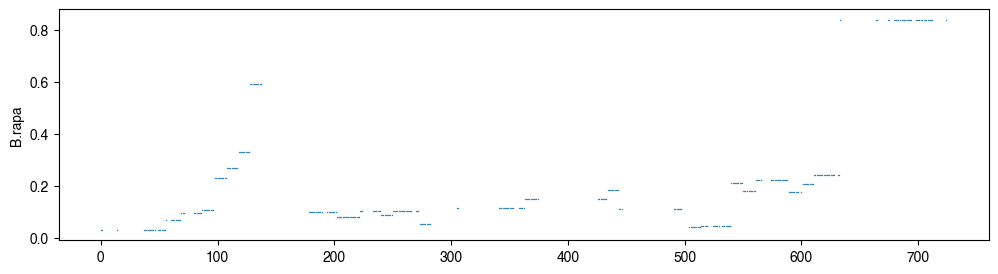

In [44]:
plt.figure(figsize = (12, 3))
# plt.imshow(pd.DataFrame(activities_aligned_df.iloc[0]).T)
sns.scatterplot(activities_aligned_df.iloc[0], s = 1)

In [45]:
order = avg_activities.groupby("name").max().sort_values(by = "range", ascending = False).index
order

Index(['MarchantiaPolymorpha', 'Nelumbonucifera', 'B.distachyon',
       'PhyscomitriumPatens', 'S.bicolor', 'B.rapa', 'Q6NQK2',
       'Nicotianatabacum(tobacco)', 'E.grandis', 'G.max', 'PopulusTrichocarpa',
       'V.vinifera', 'OryzaSativa', 'ZeaMays', 'Amborellatrichopoda',
       'Selaginellamoellendorffii(spikemoss)'],
      dtype='object', name='name')

In [46]:
activities_aligned_df

,0,1,2,3,4,5,6,7,8,9,...,724,725,726,727,728,729,730,731,732,733
name,,,,,,,,,,,,,,,,,,,,,
B.rapa,0.031225,0.031225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.838376,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S.bicolor,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.075378,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075378
E.grandis,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.653108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
V.vinifera,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P.trichocarpa,0.140665,0.140665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.578699,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N.tabacum,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.086378,0.086378,0.086378,0.086378,0.086378,NaN,NaN,NaN,0.086378,0.086378
G.max,0.058601,0.058601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
S.moellendorffii,0.074009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
M.polymorpha,0.219281,0.219281,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.302289,NaN,0.302289,0.302289,0.120454,NaN,NaN,NaN,0.120454,0.120454


In [47]:
import matplotlib.pyplot as plt
from Bio import Phylo
import seaborn as sns

tree1 = Phylo.read("../data/sog1_orthologs_tree", "newick")


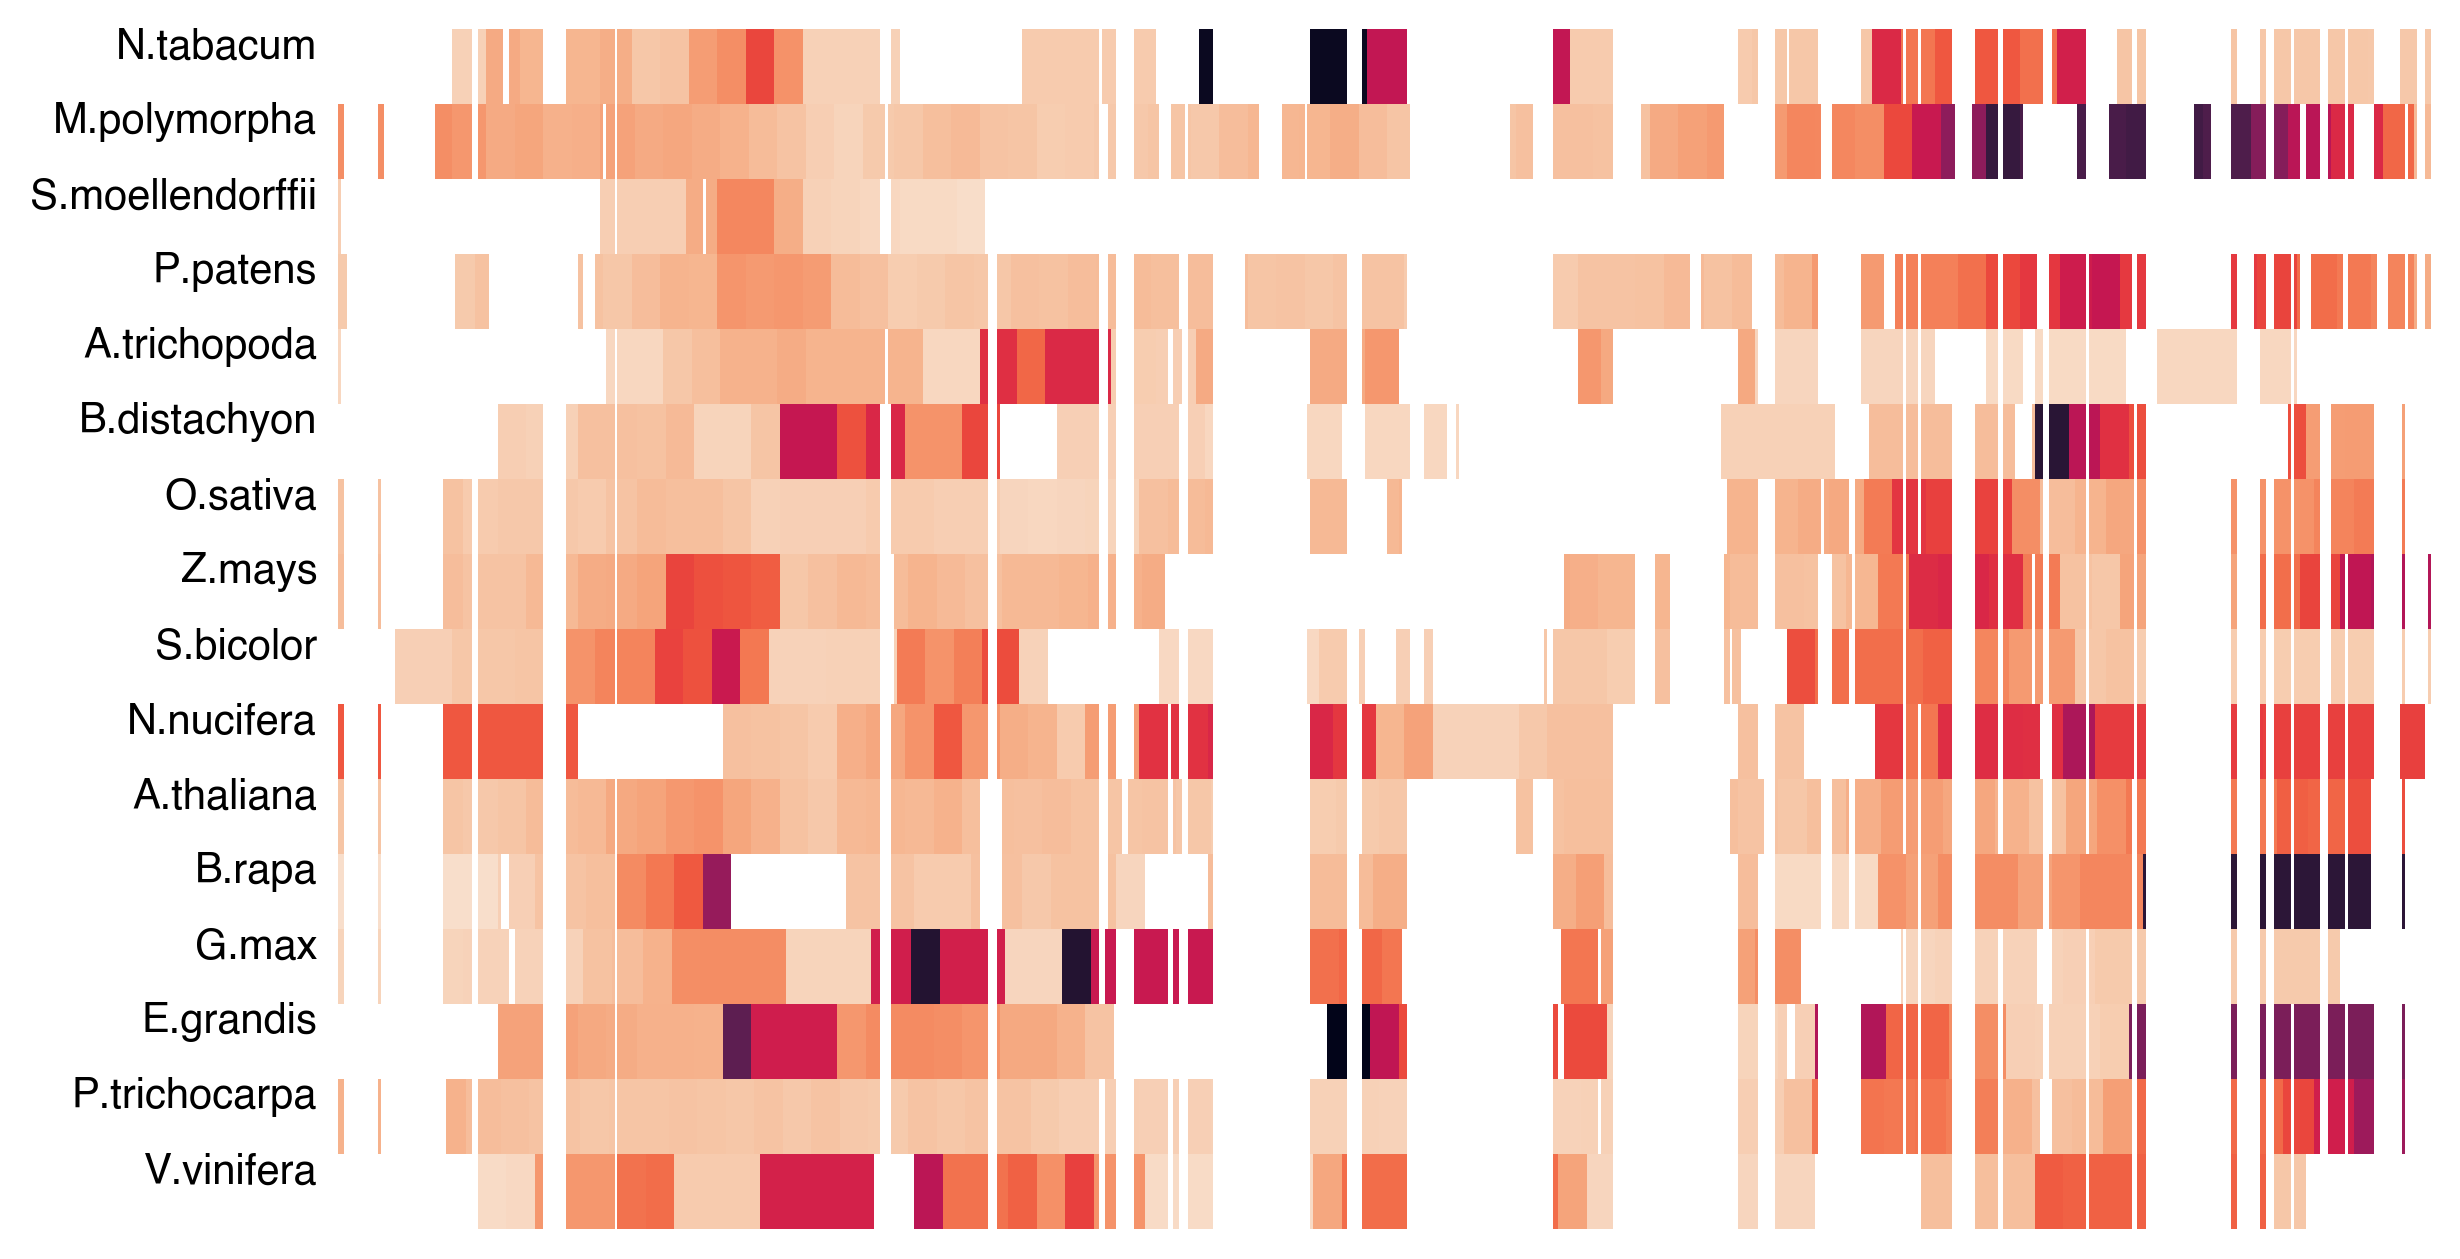

In [48]:
name_order = []
for entry in tree1.get_terminals():
   name_order.append(entry.name)


fig, axs = plt.subplots(16,1, figsize = (8, 4), dpi = 300)

for i in np.arange(16):
    label = name_order[len(name_order) - 1 -i]
    axs[i].imshow([activities_aligned_df.loc[label]], aspect="auto", interpolation="none", extent=[0, 733, 0, 1], cmap = "rocket_r", vmin = 0, vmax = 0.95)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_ylabel(label, rotation = 0, ha = "right", labelpad = 5)
    
sns.despine(left = True, bottom = True)
plt.tight_layout(pad = 0)

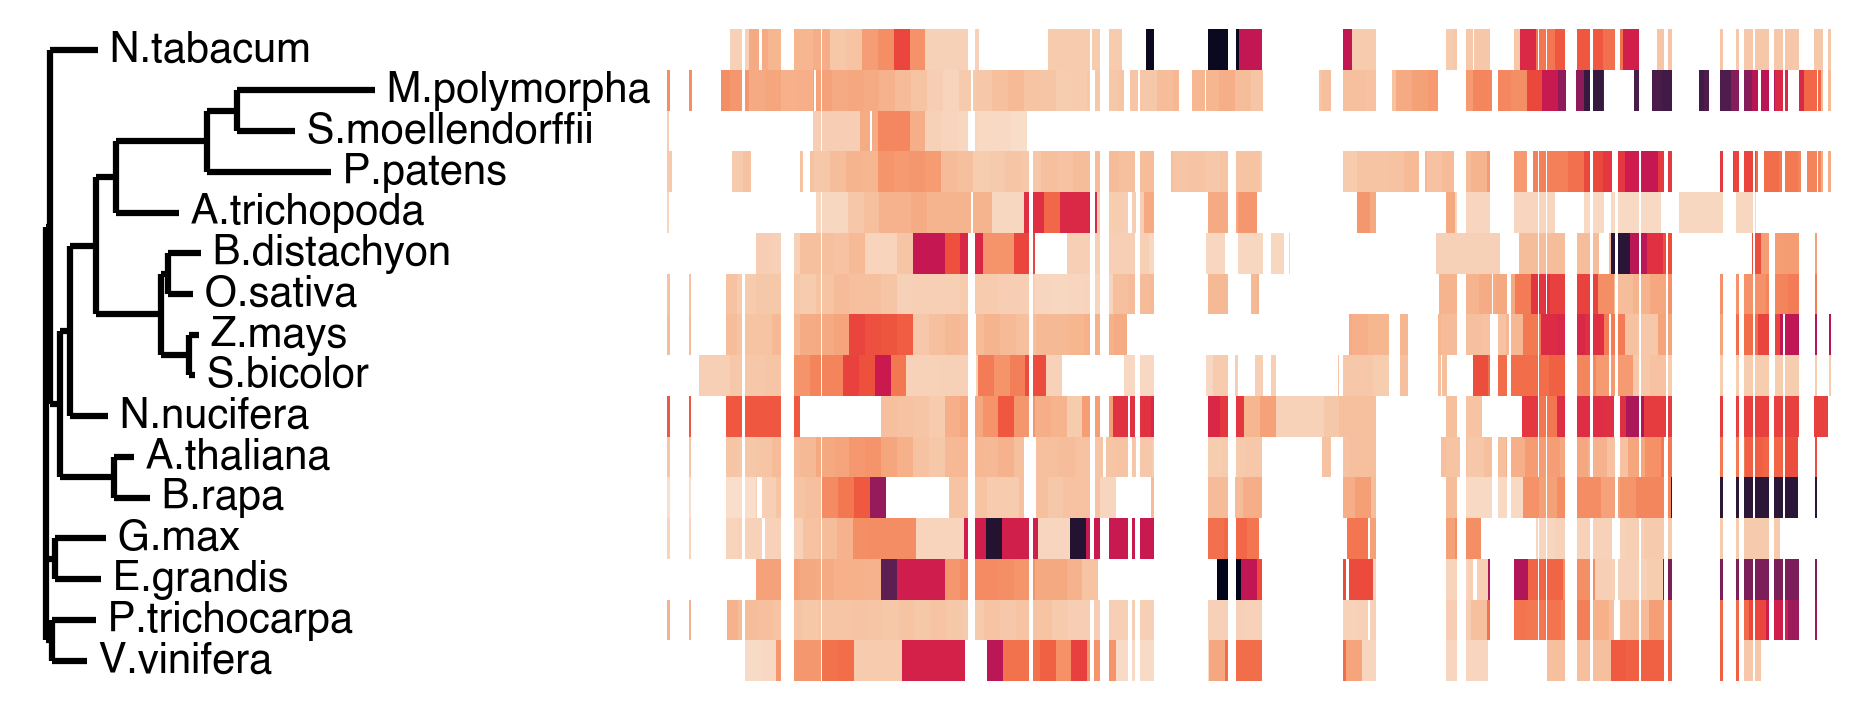

In [49]:
fig = plt.figure(figsize=(6,2.2), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [1.1, 3])

ax0 = fig.add_subplot(spec[:, 0])


# Draw tree
# Draw the first tree in the first subplot
Phylo.draw(tree1, do_show=False, axes=ax0, show_confidence=False)  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

# for i in range(len(name_order)):
#     ax_i = fig.add_subplot(spec[i, 1])
#     plot_one_trace(name_order[len(name_order) - i - 1], ax_i, heatmap_df)
    
#     if name != "BasicMaPo":
#         ax_i.set_xticks([])

#     ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
#     ax_i.set_ylabel("")

# for i in range(len(name_order)):
#     ax_i = fig.add_subplot(spec[i, 1])
#     std_name = name_order[len(name_order) - 1 -i]
#     # print(std_name)
#     # display(avg_activities_with_std_names["standard_name"].value_counts())
#     input_name = avg_activities_with_std_names[avg_activities_with_std_names["standard_name"] == std_name]["name"].iloc[0]
#     plot_one_trace(input_name, ax_i)
#     ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
#     ax_i.set_xticks([])
#     ax_i.set_xticklabels([])
#     ax_i.set_ylabel("")

# ax_i.set_xticks([-100, 0, 100])
# ax_i.set_xticklabels([-100, 0, 100])

# motif_align = "RWHKTG"
# ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')

name_order = []
for entry in tree1.get_terminals():
   name_order.append(entry.name)


for i in np.arange(16):
    label = name_order[len(name_order) - 1 -i]
    ax_i = fig.add_subplot(spec[i, 1])
    ax_i.imshow([activities_aligned_df.loc[label]], aspect="auto", interpolation="none", extent=[0, 733, 0, 1], cmap = "rocket_r", vmin = 0, vmax = 0.95)
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_ylabel("")

sns.despine(left = True, bottom = True)

    
# ax10 = fig.add_subplot(spec[0, 1])
# annotate_axes(ax10, 'ax10')

# ax10 = fig.add_subplot(spec[1, 1])
# annotate_axes(ax10, 'ax10')

# ax11 = fig.add_subplot(spec[1, 1])
# annotate_axes(ax11, 'ax11')

plt.tight_layout(pad = 0)

plt.savefig("../output/figures/conservation/full_protein_tree.png", bbox_inches='tight')

#fig.suptitle('Manually added subplots, spanning a column')

In [50]:
# Species tree from https://www.ncbi.nlm.nih.gov/Taxonomy/CommonTree/wwwcmt.cgi
tree = Phylo.read("../data/phyliptree (1).phy", "newick")

In [51]:
full_to_abbreviation_map = {
    'Vitis vinifera': 'V.vinifera',
    'Populus trichocarpa': 'P.trichocarpa',
    'Eucalyptus grandis': 'E.grandis',
    'Glycine max': 'G.max',
    'Brassica rapa': 'B.rapa',
    'Arabidopsis thaliana': 'A.thaliana',
    'Nelumbo nucifera': 'N.nucifera',
    'Sorghum bicolor': 'S.bicolor',
    'Zea mays': 'Z.mays',
    'Oryza sativa': 'O.sativa',
    'Brachypodium distachyon': 'B.distachyon',
    'Amborella trichopoda': 'A.trichopoda',
    'Physcomitrium patens': 'P.patens',
    'Selaginella moellendorffii': 'S.moellendorffii',
    'Marchantia polymorpha': 'M.polymorpha',
    'Nicotiana tabacum': 'N.tabacum'
}


In [52]:
for clade in tree.find_clades():
    if clade.name in full_to_abbreviation_map.keys():
        clade.name = full_to_abbreviation_map[clade.name]

In [53]:
taxon_order = []
for entry in tree.get_terminals():
   taxon_order.append(entry.name)
taxon_order

['S.moellendorffii',
 'A.trichopoda',
 'Z.mays',
 'S.bicolor',
 'B.distachyon',
 'O.sativa',
 'N.nucifera',
 'N.tabacum',
 'V.vinifera',
 'E.grandis',
 'B.rapa',
 'A.thaliana',
 'G.max',
 'P.trichocarpa',
 'P.patens',
 'M.polymorpha']

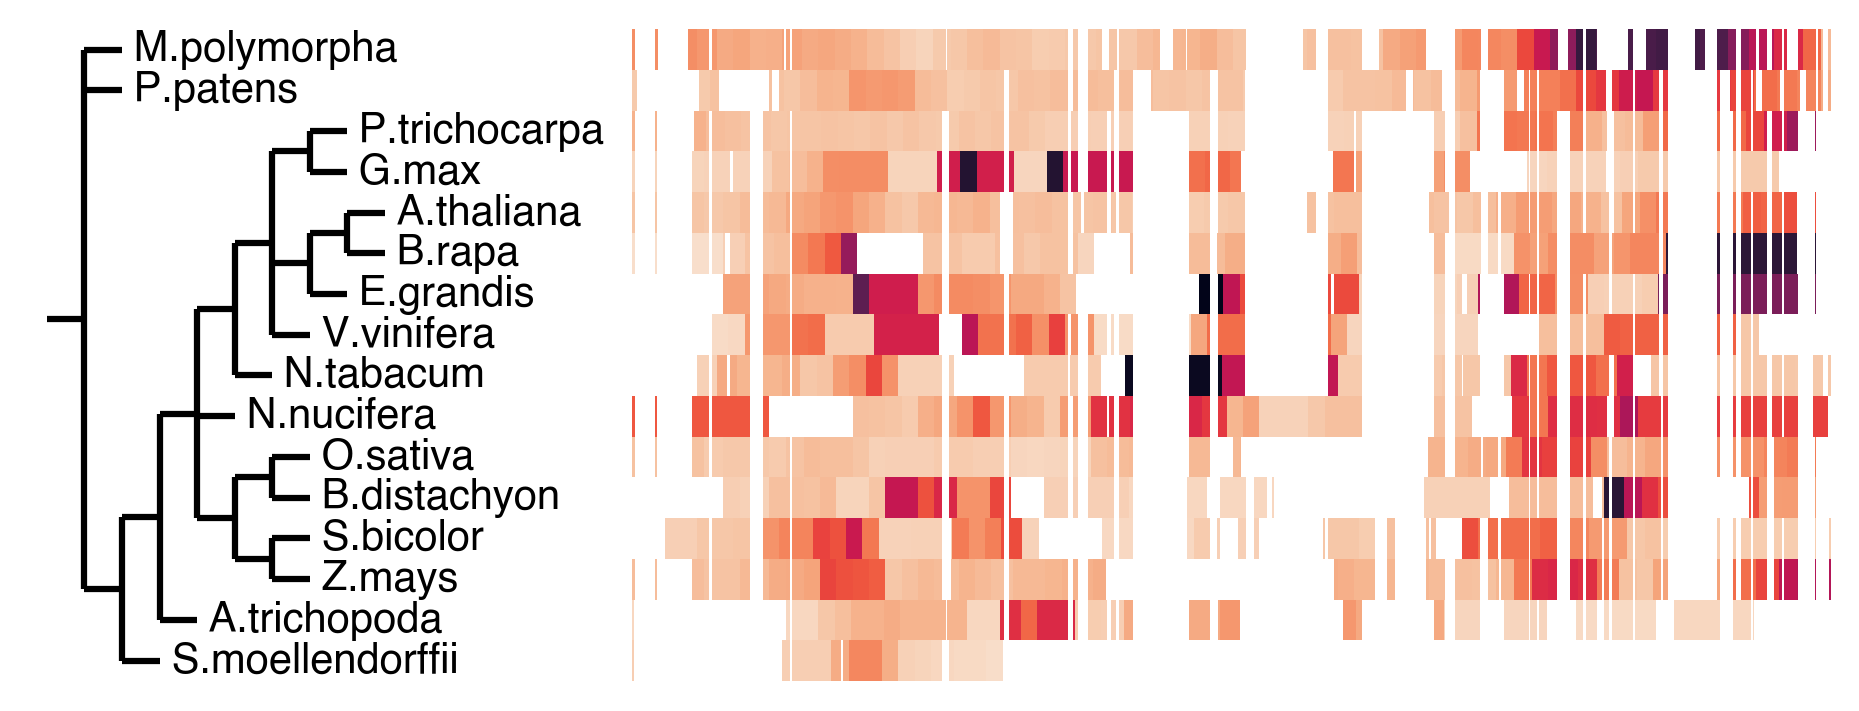

In [54]:
fig = plt.figure(figsize=(6,2.2), dpi = 300)
spec = fig.add_gridspec(16,2, width_ratios = [1.1, 3])

ax0 = fig.add_subplot(spec[:, 0])

# Draw tree
# Draw the first tree in the first subplot


Phylo.draw(tree, do_show=False, 
           axes=ax0, 
           show_confidence=False, 
           label_func=lambda clade: clade.name if clade.is_terminal() else "")  # Pass axes to the draw function
sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
ax0.set_xticks([])
ax0.set_yticks([])
#axs[0].set_title("Tree 1")  # Set title for the first tree
ax0.set_xlabel("")
ax0.set_ylabel("")
ax0.set_ylim(0.5,16.5)

# for i in range(len(name_order)):
#     ax_i = fig.add_subplot(spec[i, 1])
#     plot_one_trace(name_order[len(name_order) - i - 1], ax_i, heatmap_df)
    
#     if name != "BasicMaPo":
#         ax_i.set_xticks([])

#     ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
#     ax_i.set_ylabel("")

# for i in range(len(name_order)):
#     ax_i = fig.add_subplot(spec[i, 1])
#     std_name = name_order[len(name_order) - 1 -i]
#     # print(std_name)
#     # display(avg_activities_with_std_names["standard_name"].value_counts())
#     input_name = avg_activities_with_std_names[avg_activities_with_std_names["standard_name"] == std_name]["name"].iloc[0]
#     plot_one_trace(input_name, ax_i)
#     ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
#     ax_i.set_xticks([])
#     ax_i.set_xticklabels([])
#     ax_i.set_ylabel("")

# ax_i.set_xticks([-100, 0, 100])
# ax_i.set_xticklabels([-100, 0, 100])

# motif_align = "RWHKTG"
# ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')


for i in np.arange(16):
    #print(taxon_order[len(taxon_order) - 1 -i])
    #label = full_to_abbreviation_map[taxon_order[len(taxon_order) - 1 -i]]    
    label = taxon_order[len(taxon_order) - 1 -i]
    ax_i = fig.add_subplot(spec[i, 1])
    ax_i.imshow([activities_aligned_df.loc[label]], aspect="auto", interpolation="none", extent=[0, 733, 0, 1], cmap = "rocket_r", vmin = 0, vmax = 0.95)
    ax_i.set_xticks([])
    ax_i.set_yticks([])
    ax_i.set_ylabel("")

sns.despine(left = True, bottom = True)

    
# ax10 = fig.add_subplot(spec[0, 1])
# annotate_axes(ax10, 'ax10')

# ax10 = fig.add_subplot(spec[1, 1])
# annotate_axes(ax10, 'ax10')

# ax11 = fig.add_subplot(spec[1, 1])
# annotate_axes(ax11, 'ax11')

plt.tight_layout(pad = 0)

plt.savefig("../output/figures/conservation/full_species_tree.png", bbox_inches='tight')
#fig.suptitle('Manually added subplots, spanning a column')

# Centered on DBD

In [55]:
# avg_activities["name"] = avg_activities["name"].str.split(" ").str[0]
# avg_activities

In [56]:
# avg_activities["name"].value_counts()

In [57]:
avg_activities_with_std_names

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range,Other,Description_name,standard_name
0,Amborellatrichopoda,1,0.050786,21.0,-82.0,-102.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
1,Amborellatrichopoda,2,0.050786,21.0,-82.0,-101.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
2,Amborellatrichopoda,3,0.050786,21.0,-82.0,-100.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
3,Amborellatrichopoda,4,0.050786,21.0,-82.0,-99.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
4,Amborellatrichopoda,5,0.050786,21.0,-82.0,-98.0,Amborellatrichopoda_W1NK30_TAIR,BasicAmTr,A.trichopoda
...,...,...,...,...,...,...,...,...,...
6985,ZeaMays,416,0.527065,401.0,253.0,268.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays
6986,ZeaMays,417,0.527065,401.0,253.0,269.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays
6987,ZeaMays,418,0.527065,401.0,253.0,270.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays
6988,ZeaMays,419,0.527065,401.0,253.0,271.0,ZeaMays_ACL54469.1,BasicZeMa,Z.mays


In [58]:
from scipy.ndimage import gaussian_filter

def plot_one_trace2(name, ax, avg_activities = avg_activities_with_std_names):
    # Extract the data
    min_x = min(avg_activities[avg_activities["name"] == name]["adj_range"])
    max_x = max(avg_activities[avg_activities["name"] == name]["adj_range"])
    data = avg_activities[avg_activities["name"] == name]["normalized_Activity_S3_1"]
    
    # Apply Gaussian filter (you can tweak the sigma parameter)
    smoothed_data = gaussian_filter(data, sigma=3)  # Adjust sigma for different smoothing
    
    # Reshape the data to match the shape expected by imshow
    smoothed_data_reshaped = smoothed_data.reshape(1, -1)  # Reshape to a 2D array
    #print(smoothed_data_reshaped)
    
    # Plot the smoothed data using imshow
    ax.imshow(smoothed_data_reshaped, vmin=0, vmax=0.95, extent=[min_x - 5, max_x + 5, 0, 20], cmap='rocket_r', interpolation='none')
    
    # # Customize the plot
    # ax.set_yticks([])
    # ax.set_xlim(min(avg_activities["adj_range"]), max(avg_activities["adj_range"]))
    # ax.set_ylabel(name, rotation=0, va='center', ha='right', labelpad=15)
    
    # # Remove spines
    # sns.despine(left=True, bottom=True, ax=ax)


In [59]:
avg_activities

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range
0,Amborellatrichopoda,1,0.050786,21.0,-82.0,-102.0
1,Amborellatrichopoda,2,0.050786,21.0,-82.0,-101.0
2,Amborellatrichopoda,3,0.050786,21.0,-82.0,-100.0
3,Amborellatrichopoda,4,0.050786,21.0,-82.0,-99.0
4,Amborellatrichopoda,5,0.050786,21.0,-82.0,-98.0
...,...,...,...,...,...,...
6985,ZeaMays,416,0.527065,401.0,253.0,268.0
6986,ZeaMays,417,0.527065,401.0,253.0,269.0
6987,ZeaMays,418,0.527065,401.0,253.0,270.0
6988,ZeaMays,419,0.527065,401.0,253.0,271.0


In [60]:
min(avg_activities["normalized_Activity_S3_1"])

0.0312250718171977

In [61]:
max(avg_activities["normalized_Activity_S3_1"])

0.9574601583319888

In [62]:
def plot_one_trace(name, ax, avg_activities = avg_activities_with_std_names):
    min_x = min(avg_activities[avg_activities["name"] == name]["adj_range"])
    max_x = max(avg_activities[avg_activities["name"] == name]["adj_range"])
    
    start =  min_x -5  
    end = max_x + 5
    
    data = avg_activities[avg_activities["name"] == name]["normalized_Activity_S3_1"]
    
    smoothed_data = gaussian_filter(data, sigma=3)
    smoothed_data_reshaped = smoothed_data.reshape(1, -1)
    
    ax.imshow(smoothed_data_reshaped, vmin = 0, vmax = 1, extent = [min_x - 5, max_x + 5, 0, 25], cmap = 'rocket_r')
    
    #ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlim(min(avg_activities["adj_range"]) - 5, max(avg_activities["adj_range"]) + 5)
    ax.set_ylabel(avg_activities[avg_activities["name"] == name]["standard_name"].iloc[0], rotation = 0, va = 'center', ha = 'right', labelpad = 15)
    sns.despine(left = True, bottom = True, ax = ax)
    
    ax.axvline(start, color = "black", lw = 0.5)
    ax.axvline(end, color = "black", lw = 0.5)

    ax.plot((start, end), (25, 25), 'k-',linewidth=0.5)
    ax.plot((start, end), (0, 0), 'k-',linewidth=0.5)



In [63]:
avg_activities_with_std_names[avg_activities_with_std_names["standard_name"] == "S.bicolor"]

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range,Other,Description_name,standard_name
5470,S.bicolor,1,NaN,21.0,-161.0,-181.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5471,S.bicolor,2,NaN,21.0,-161.0,-180.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5472,S.bicolor,3,NaN,21.0,-161.0,-179.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5473,S.bicolor,4,NaN,21.0,-161.0,-178.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5474,S.bicolor,5,NaN,21.0,-161.0,-177.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
...,...,...,...,...,...,...,...,...,...
5955,S.bicolor,486,0.075378,471.0,289.0,304.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5956,S.bicolor,487,0.075378,471.0,289.0,305.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5957,S.bicolor,488,0.075378,471.0,289.0,306.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor
5958,S.bicolor,489,0.075378,471.0,289.0,307.0,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor


In [64]:
dbd_order = avg_activities[["name", "adj_range"]].groupby(["name"]).max().sort_values(by = "adj_range", ascending = False).index
dbd_order

Index(['MarchantiaPolymorpha', 'PhyscomitriumPatens', 'Nelumbonucifera',
       'B.distachyon', 'S.bicolor', 'Amborellatrichopoda', 'B.rapa', 'Q6NQK2',
       'Nicotianatabacum(tobacco)', 'V.vinifera', 'G.max',
       'PopulusTrichocarpa', 'E.grandis', 'ZeaMays', 'OryzaSativa',
       'Selaginellamoellendorffii(spikemoss)'],
      dtype='object', name='name')

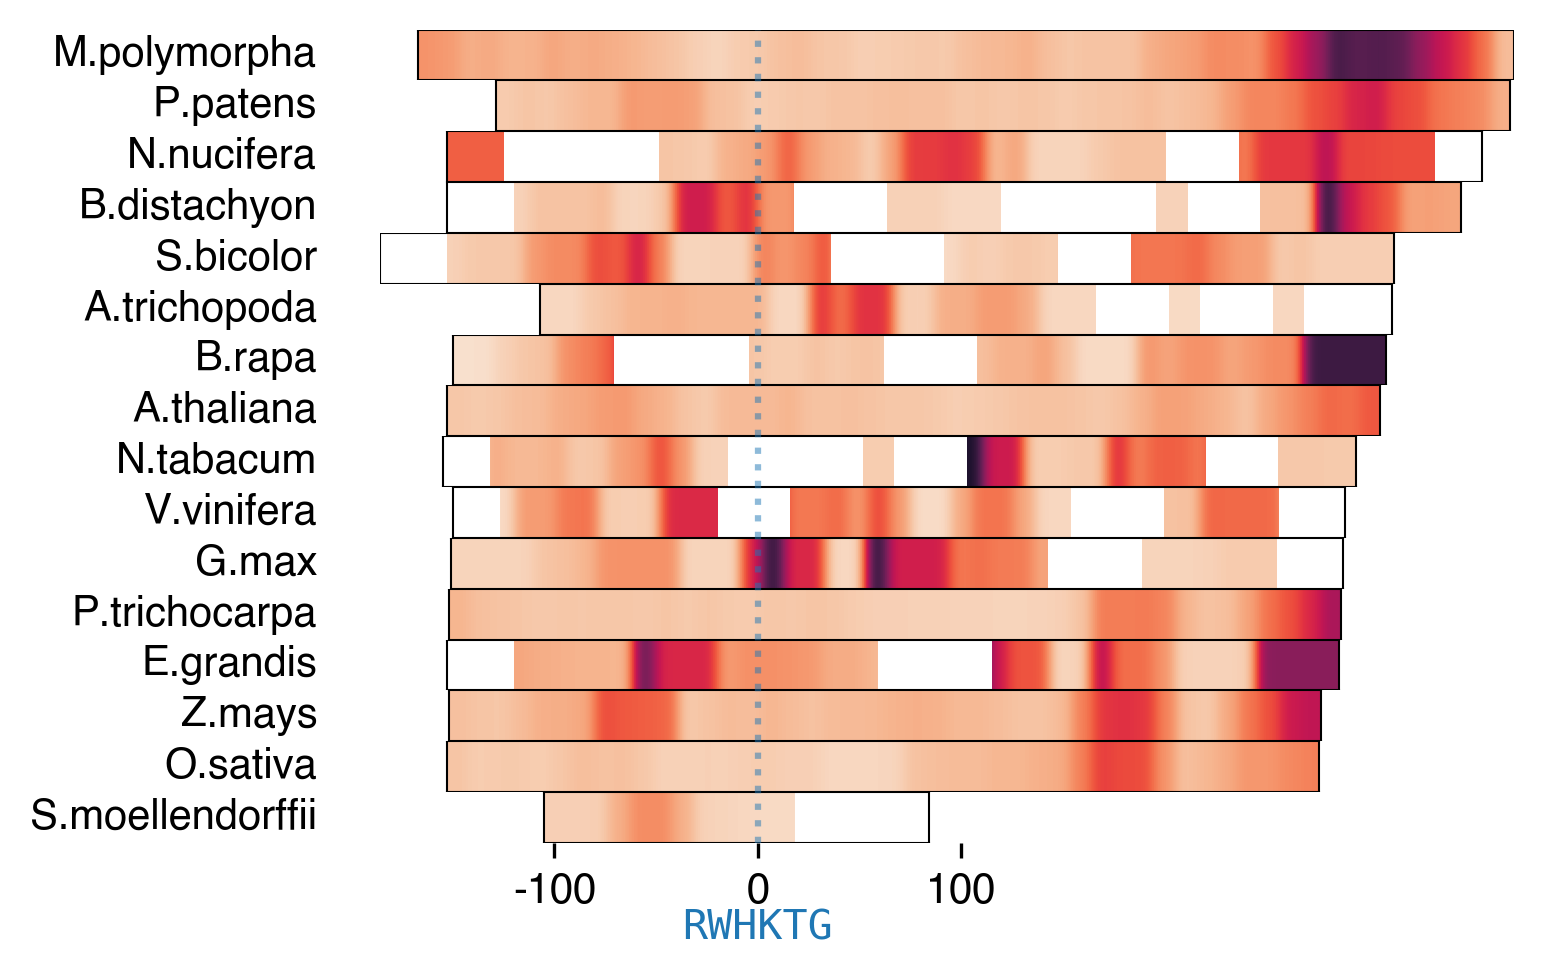

In [65]:
fig, axs = plt.subplots(16, 1, sharex = True, figsize = (6, 3), dpi = 300)
for i in np.arange(16):
    plot_one_trace(dbd_order[i], axs[i])
    axs[i].axvline(0, alpha = 0.5, linestyle = 'dotted')
    axs[i].set_xticks([])
    axs[i].set_xticklabels([])

axs[-1].set_xticks([-100, 0, 100])
axs[-1].set_xticklabels([-100, 0, 100])
axs[-1].text(x = 0, y = -32, va = "top", ha = "center", s = "RWHKTG", color = sns.color_palette("tab10")[0], font = 'monospace')

plt.tight_layout(pad = 0)

In [66]:
avg_activities_with_std_names["name"] = avg_activities_with_std_names["name"].str.split(" ").str[0]
avg_activities_with_std_names["name"].value_counts()

name
MarchantiaPolymorpha                    530
Nelumbonucifera                         500
B.distachyon                            490
PhyscomitriumPatens                     490
S.bicolor                               490
B.rapa                                  450
Q6NQK2                                  450
Nicotianatabacum(tobacco)               440
E.grandis                               430
G.max                                   430
PopulusTrichocarpa                      430
V.vinifera                              430
OryzaSativa                             420
ZeaMays                                 420
Amborellatrichopoda                     410
Selaginellamoellendorffii(spikemoss)    180
Name: count, dtype: int64

In [67]:
avg_activities_with_std_names[avg_activities_with_std_names["standard_name"].isna()]

,name,range,normalized_Activity_S3_1,mid,adj_mid,adj_range,Other,Description_name,standard_name


In [68]:
min(avg_activities_with_std_names["normalized_Activity_S3_1"])

0.0312250718171977

In [69]:
max(avg_activities_with_std_names["normalized_Activity_S3_1"])

0.9574601583319888

In [70]:
def plot_next_to_tree(tree1):
    name_order = []
    for entry in tree1.get_terminals():
       name_order.append(entry.name)
        
    fig = plt.figure(figsize=(6.45,3.3), dpi = 300)
    spec = fig.add_gridspec(16,2, width_ratios = [1.1, 3])
    
    ax0 = fig.add_subplot(spec[:, 0])

    for clade in tree1.find_clades():
        if clade.name in full_to_abbreviation_map.keys():
            clade.name = full_to_abbreviation_map[clade.name]
        
    # Draw tree
    # Draw the first tree in the first subplot
    Phylo.draw(tree1, do_show=False, axes=ax0, show_confidence=False, label_func=lambda clade: clade.name if clade.is_terminal() else "")  # Pass axes to the draw function
    sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
    ax0.set_xticks([])
    ax0.set_yticks([])
    #axs[0].set_title("Tree 1")  # Set title for the first tree
    ax0.set_xlabel("")
    ax0.set_ylabel("")
    ax0.set_ylim(0.5,16.5)
    
    # for i in range(len(name_order)):
    #     ax_i = fig.add_subplot(spec[i, 1])
    #     plot_one_trace(name_order[len(name_order) - i - 1], ax_i, heatmap_df)
        
    #     if name != "BasicMaPo":
    #         ax_i.set_xticks([])
    
    #     ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
    #     ax_i.set_ylabel("")

    
    for i in range(len(name_order)):
        ax_i = fig.add_subplot(spec[i, 1])
        std_name = name_order[len(name_order) - 1 -i]

        if "." not in std_name:
            std_name = full_to_abbreviation_map[std_name]
        # print(std_name)
        # display(avg_activities_with_std_names["standard_name"].value_counts())
        input_name = avg_activities_with_std_names[avg_activities_with_std_names["standard_name"] == std_name]["name"].iloc[0]
        plot_one_trace(input_name, ax_i)
        ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
        ax_i.set_xticks([])
        ax_i.set_xticklabels([])
        ax_i.set_ylabel("")
    
    ax_i.set_xticks([-100, 0, 100])
    ax_i.set_xticklabels([-100, 0, 100])
    
    motif_align = "RWHKTG"
    ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')
    
    
    # ax10 = fig.add_subplot(spec[0, 1])
    # annotate_axes(ax10, 'ax10')
    
    # ax10 = fig.add_subplot(spec[1, 1])
    # annotate_axes(ax10, 'ax10')
    
    # ax11 = fig.add_subplot(spec[1, 1])
    # annotate_axes(ax11, 'ax11')
    
    plt.tight_layout(pad = 0)
    
    #fig.suptitle('Manually added subplots, spanning a column')

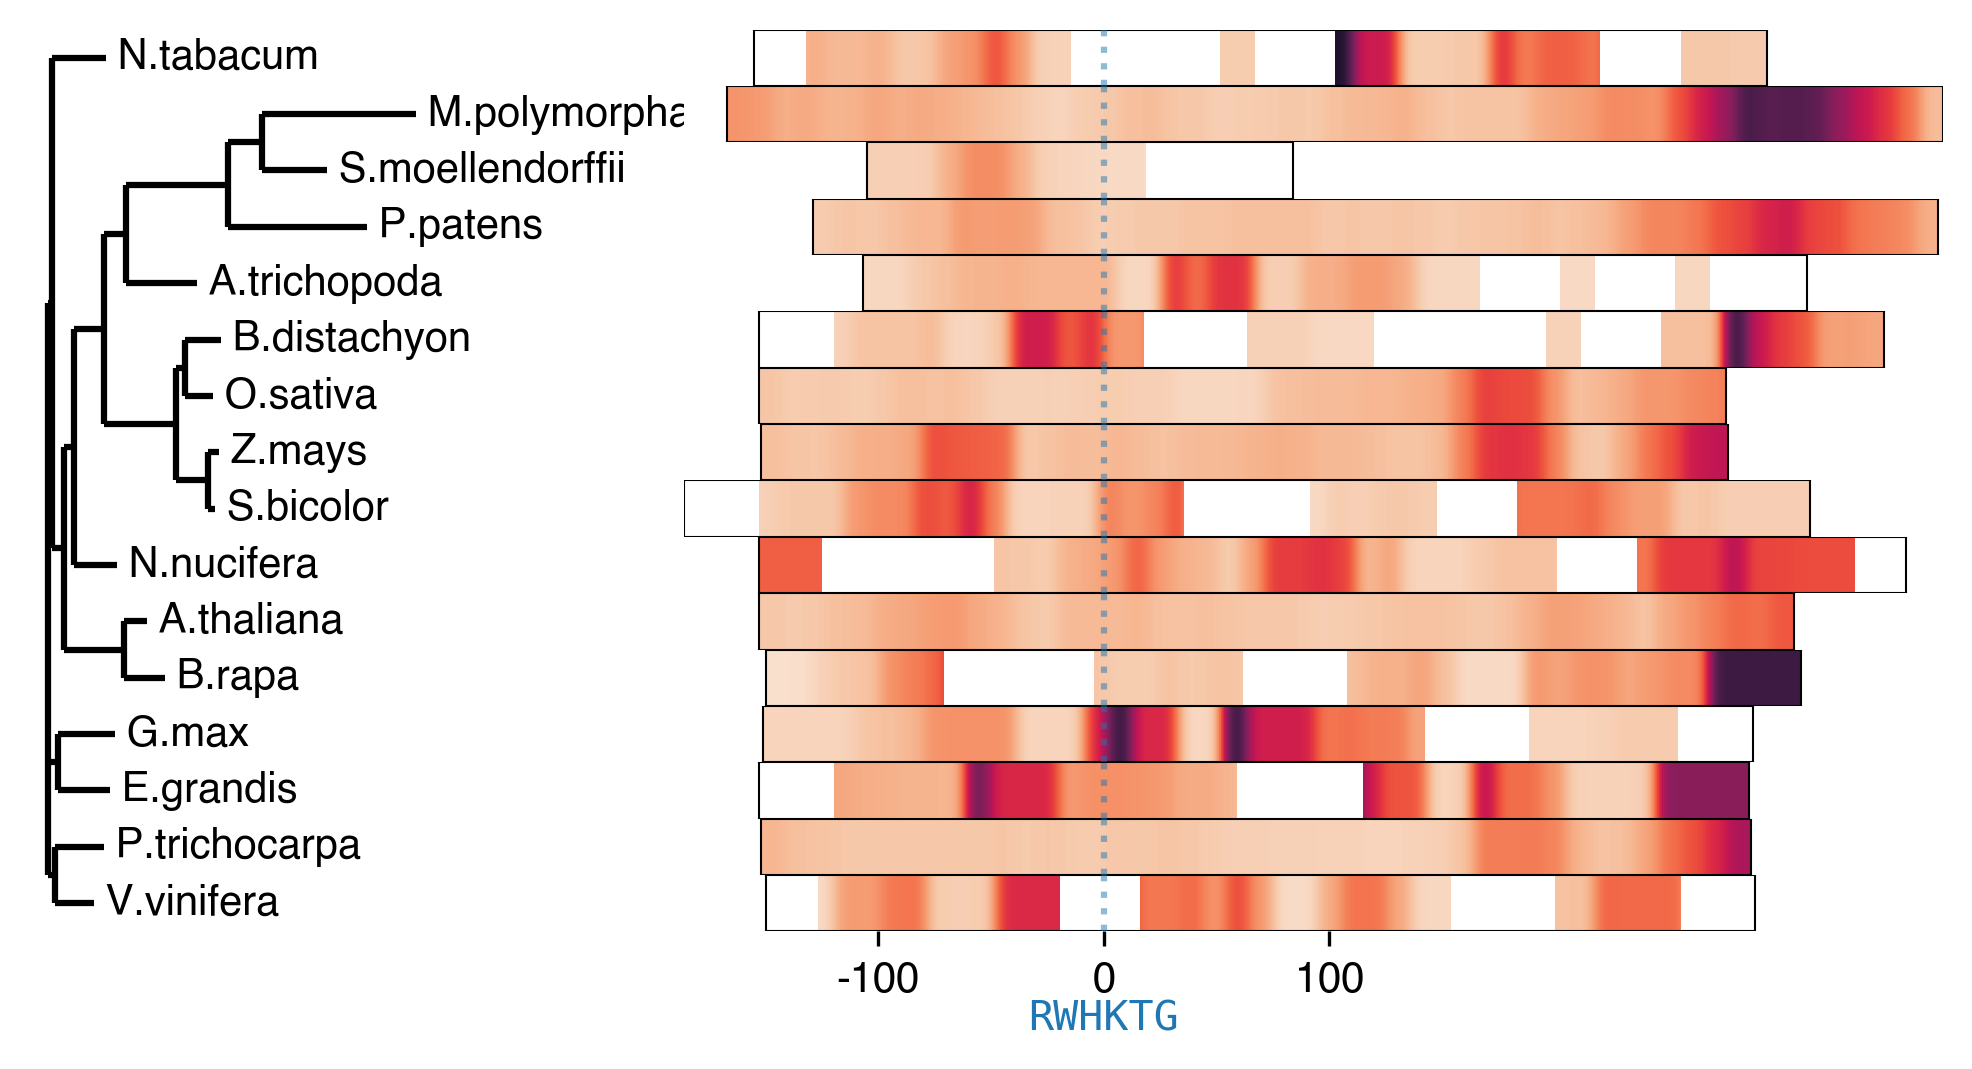

In [71]:
plot_next_to_tree(tree1)

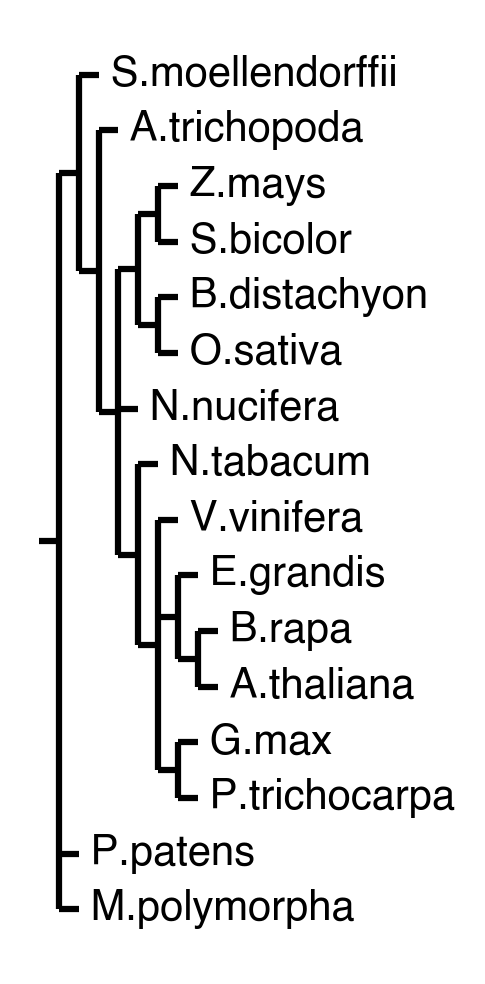

In [72]:
fig, ax = plt.subplots(figsize = (1,4), dpi = 300)

Phylo.draw(tree, 
           do_show=False, 
           show_confidence=False, 
           label_func=lambda clade: clade.name if clade.is_terminal() else "", axes = ax)
sns.despine(left = True, bottom = True, ax = ax)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xlabel("")
ax.set_ylabel("");



In [73]:
name_order

['V.vinifera',
 'P.trichocarpa',
 'E.grandis',
 'G.max',
 'B.rapa',
 'A.thaliana',
 'N.nucifera',
 'S.bicolor',
 'Z.mays',
 'O.sativa',
 'B.distachyon',
 'A.trichopoda',
 'P.patens',
 'S.moellendorffii',
 'M.polymorpha',
 'N.tabacum']

In [74]:
taxon_order

['S.moellendorffii',
 'A.trichopoda',
 'Z.mays',
 'S.bicolor',
 'B.distachyon',
 'O.sativa',
 'N.nucifera',
 'N.tabacum',
 'V.vinifera',
 'E.grandis',
 'B.rapa',
 'A.thaliana',
 'G.max',
 'P.trichocarpa',
 'P.patens',
 'M.polymorpha']

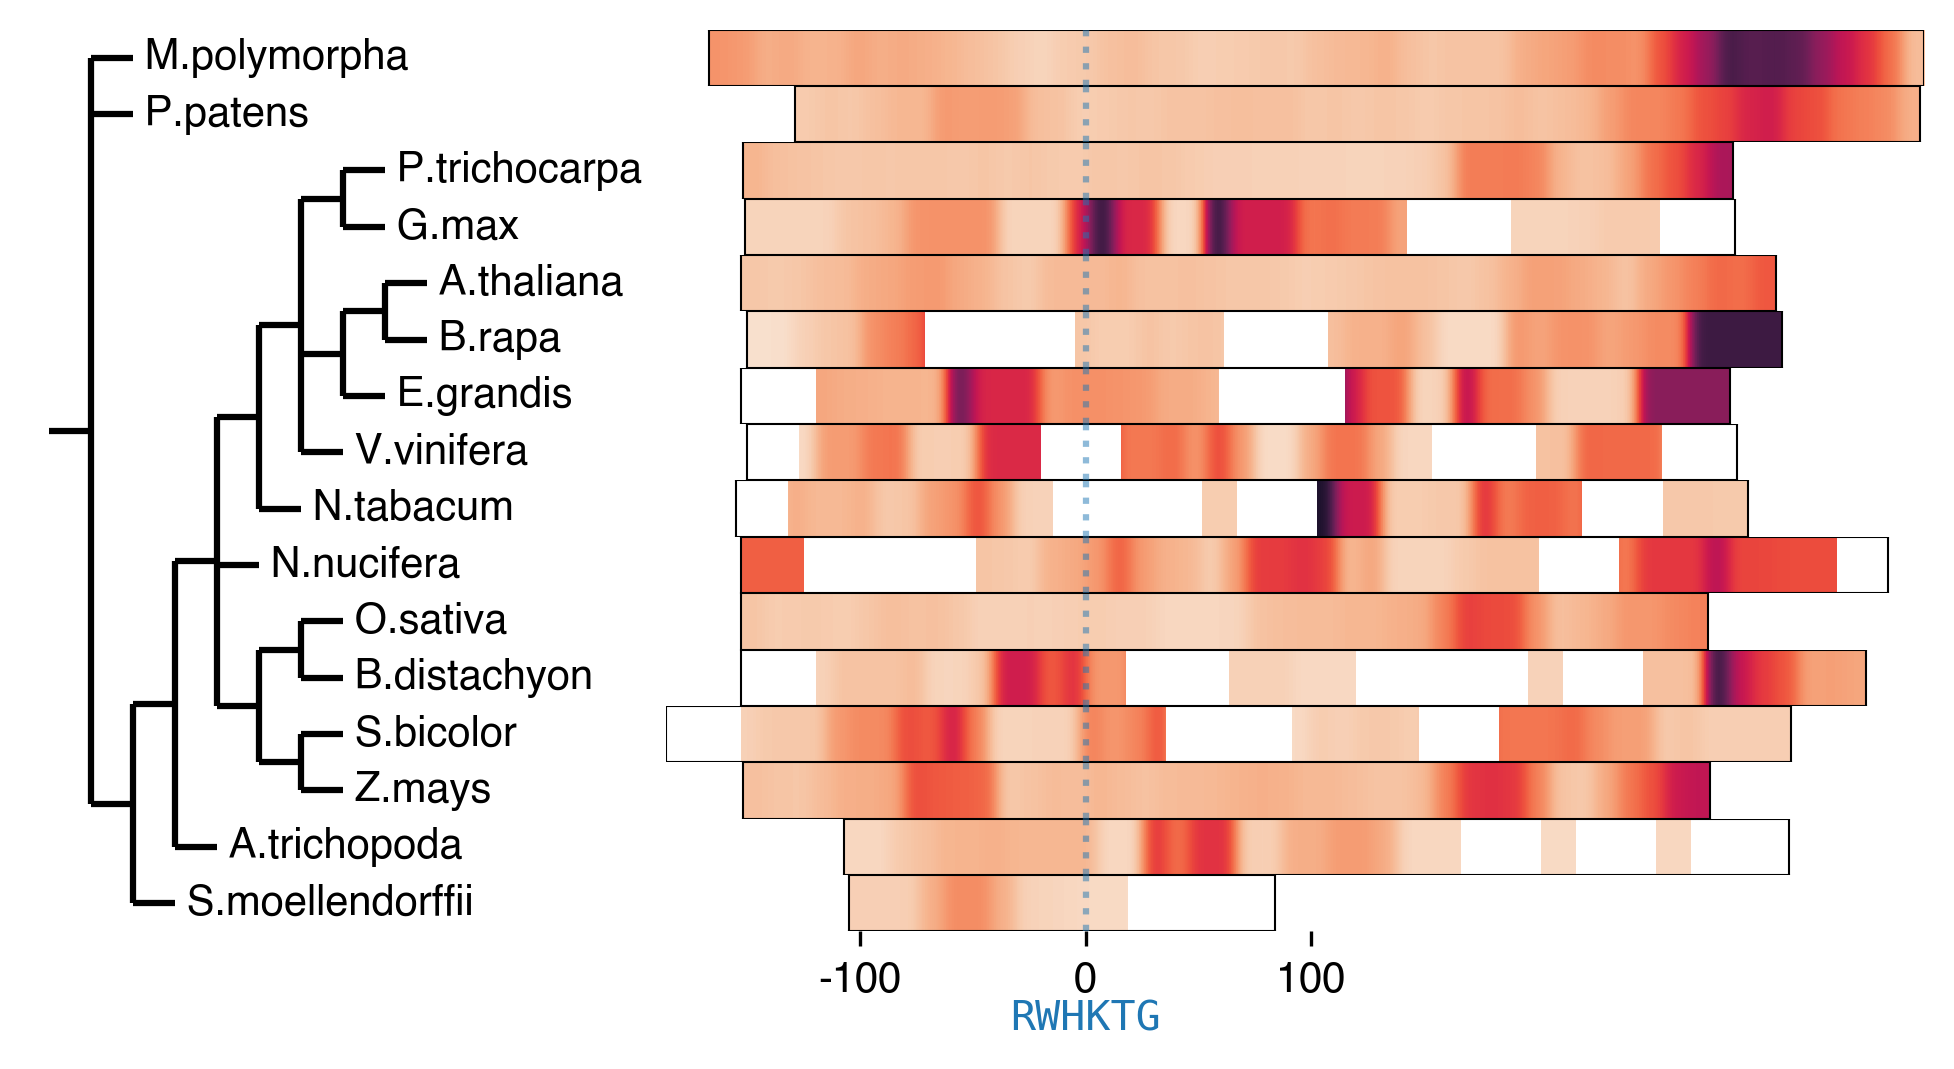

In [75]:
plot_next_to_tree(tree)

In [76]:
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [77]:
def return_positions(string, substring):
    def return_positions_helper(string, substring, pos, positions):
        window_size = len(substring)
        if len(string) == 0:
            return positions
        if string[:window_size] == substring:
            positions.append(pos)
            string = string[window_size:]
            pos += window_size - 1
        else:
            string = string[1:]
            
        return return_positions_helper(string, substring, pos + 1, positions)

    return return_positions_helper(string, substring, 1, [])

def return_positions_multip_strs(string, substring1, substring2):
    matches_1 = return_positions(string, substring1)
    matches_2 = return_positions(string, substring2)
    return list(set(matches_1).union(set(matches_2)))

In [78]:
other_to_descrip

,Other,Description_name,standard_name,name
471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa
567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor,S.bicolor
687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr,E.grandis,E.grandis
779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi,V.vinifera,V.vinifera
867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr,P.trichocarpa,PopulusTrichocarpa
961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa,N.tabacum,Nicotianatabacum(tobacco)
1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa,G.max,G.max
1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo,S.moellendorffii,Selaginellamoellendorffii(spikemoss)
1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo,M.polymorpha,MarchantiaPolymorpha
1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa,P.patens,PhyscomitriumPatens


In [79]:
#sog1_orthologs["potential_PS"] = sog1_orthologs["Unnamed: 1"].str.findall("SQ")
sog1_orthologs["potential_PS"] = [return_positions_multip_strs(seq, "SQ", "TP") for seq in sog1_orthologs["Unnamed: 1"]]
sog1_orthologs["name"] = sog1_orthologs["name"].str.split(" ").str[0]
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name,potential_PS
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa,"[419, 426, 366, 238, 432, 82, 245, 342, 250, 348]"
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor,"[386, 393, 44, 473, 468, 376, 409, 411]"
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis,"[350, 402, 328, 409, 252, 334, 415]"
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera,"[417, 350, 242, 404, 247, 328, 411, 334]"
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa,"[401, 244, 249, 351, 408, 329, 414, 335]"
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco),"[355, 419, 339, 406, 248, 253, 333, 413]"
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max,"[248, 402, 323, 243, 408, 329, 394, 345]"
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss),[2]
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha,"[320, 468, 501, 358, 489, 286]"
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens,"[137, 459, 447, 479]"


In [80]:
sog1_orthologs_PS = pd.merge(sog1_orthologs, other_to_descrip[["name", "standard_name"]], how = "left")[["standard_name", "potential_PS"]]
sog1_orthologs_PS = dict(zip(sog1_orthologs_PS["standard_name"], sog1_orthologs_PS["potential_PS"]))
sog1_orthologs_PS

{'B.rapa': [419, 426, 366, 238, 432, 82, 245, 342, 250, 348],
 'S.bicolor': [386, 393, 44, 473, 468, 376, 409, 411],
 'E.grandis': [350, 402, 328, 409, 252, 334, 415],
 'V.vinifera': [417, 350, 242, 404, 247, 328, 411, 334],
 'P.trichocarpa': [401, 244, 249, 351, 408, 329, 414, 335],
 'N.tabacum': [355, 419, 339, 406, 248, 253, 333, 413],
 'G.max': [248, 402, 323, 243, 408, 329, 394, 345],
 'S.moellendorffii': [2],
 'M.polymorpha': [320, 468, 501, 358, 489, 286],
 'P.patens': [137, 459, 447, 479],
 'A.trichopoda': [384, 354, 199, 392, 361, 333, 365, 273, 373, 279, 377, 247],
 'O.sativa': [322, 306, 338, 340, 403, 316, 398],
 'B.distachyon': [384, 416, 400, 466, 10, 461, 394],
 'Z.mays': [393, 10, 301, 334, 398, 336, 311, 318],
 'N.nucifera': [353, 388, 455, 329, 462, 404, 468, 245, 473, 250, 382],
 'A.thaliana': [356, 423, 237, 430, 270, 372, 436, 244, 249, 350]}

In [81]:
avg_activities_with_std_names["DBD_adj"] = avg_activities_with_std_names["adj_mid"] - avg_activities_with_std_names["mid"] 
DBD_adj = avg_activities_with_std_names[["standard_name", "DBD_adj"]].drop_duplicates()
DBD_adj = dict(zip(DBD_adj["standard_name"], DBD_adj["DBD_adj"]))
DBD_adj

{'A.trichopoda': -103.0,
 'B.distachyon': -149.0,
 'B.rapa': -146.0,
 'E.grandis': -149.0,
 'G.max': -147.0,
 'M.polymorpha': -163.0,
 'N.nucifera': -149.0,
 'N.tabacum': -151.0,
 'O.sativa': -149.0,
 'P.patens': -125.0,
 'P.trichocarpa': -148.0,
 'A.thaliana': -149.0,
 'S.bicolor': -182.0,
 'S.moellendorffii': -101.0,
 'V.vinifera': -146.0,
 'Z.mays': -148.0}

In [82]:
def plot_next_to_tree_with_PS(tree1, figsize = (6.45,3.3), width_ratios = [1.1, 3]):
    name_order = []
    for entry in tree1.get_terminals():
       name_order.append(entry.name)
        
    fig = plt.figure(figsize=figsize, dpi = 300)
    spec = fig.add_gridspec(16,2, width_ratios = width_ratios)
    
    ax0 = fig.add_subplot(spec[:, 0])

    for clade in tree1.find_clades():
        if clade.name in full_to_abbreviation_map.keys():
            clade.name = full_to_abbreviation_map[clade.name]
        
    # Draw tree
    # Draw the first tree in the first subplot
    Phylo.draw(tree1, do_show=False, axes=ax0, show_confidence=False, label_func=lambda clade: clade.name if clade.is_terminal() else "")  # Pass axes to the draw function
    sns.despine(ax=ax0, left = True, bottom = True)  # Remove the top and right spines
    ax0.set_xticks([])
    ax0.set_yticks([])
    #axs[0].set_title("Tree 1")  # Set title for the first tree
    ax0.set_xlabel("")
    ax0.set_ylabel("")
    ax0.set_ylim(0.5,16.5)
    
    # for i in range(len(name_order)):
    #     ax_i = fig.add_subplot(spec[i, 1])
    #     plot_one_trace(name_order[len(name_order) - i - 1], ax_i, heatmap_df)
        
    #     if name != "BasicMaPo":
    #         ax_i.set_xticks([])
    
    #     ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
    #     ax_i.set_ylabel("")

    
    for i in range(len(name_order)):
        ax_i = fig.add_subplot(spec[i, 1])
        std_name = name_order[len(name_order) - 1 -i]

        #print(std_name)

        if "." not in std_name:
            std_name = full_to_abbreviation_map[std_name]
        # print(std_name)
        # display(avg_activities_with_std_names["standard_name"].value_counts())
        input_name = avg_activities_with_std_names[avg_activities_with_std_names["standard_name"] == std_name]["name"].iloc[0]
        plot_one_trace(input_name, ax_i)
        ax_i.axvline(0, alpha = 0.5, linestyle = 'dotted')
        ax_i.set_xticks([])
        ax_i.set_xticklabels([])
        ax_i.set_ylabel("")

        for PS in sog1_orthologs_PS[std_name]:
            ax_i.axvline(PS + DBD_adj[std_name], alpha = 0.75, linestyle = 'solid', color = 'yellow', lw = 1)
        
    
    ax_i.set_xticks([-100, 0, 100])
    ax_i.set_xticklabels([-100, 0, 100])
    
    motif_align = "RWHKTG"
    ax_i.text(x = 0, y = -30, va = "top", ha = "center", s = motif_align, color = sns.color_palette("tab10")[0], font = 'monospace')
    
    
    # ax10 = fig.add_subplot(spec[0, 1])
    # annotate_axes(ax10, 'ax10')
    
    # ax10 = fig.add_subplot(spec[1, 1])
    # annotate_axes(ax10, 'ax10')
    
    # ax11 = fig.add_subplot(spec[1, 1])
    # annotate_axes(ax11, 'ax11')
    
    plt.tight_layout(pad = 0)
    
    #fig.suptitle('Manually added subplots, spanning a column')

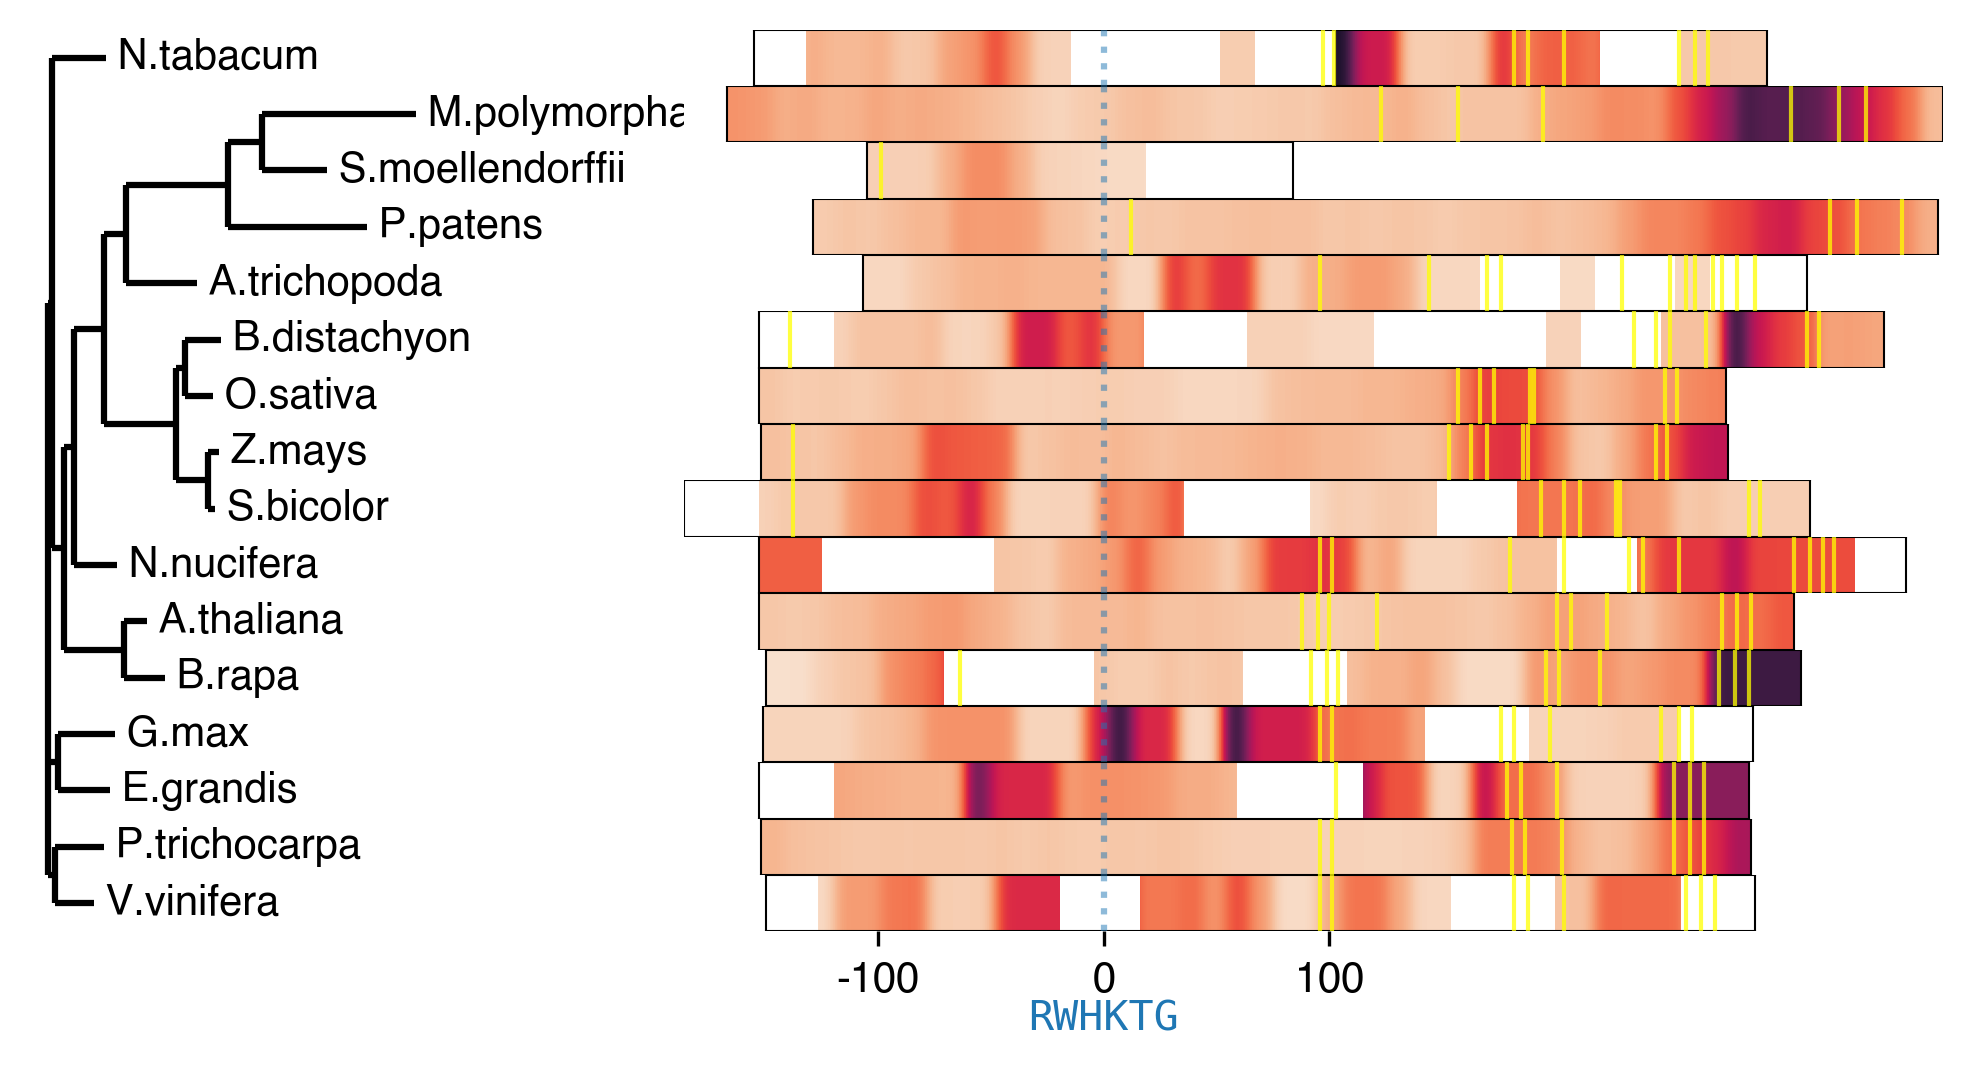

In [83]:
plot_next_to_tree_with_PS(tree1)
plt.savefig("../output/figures/conservation/DBD_protein_tree.png", bbox_inches='tight')

In [84]:
! mkdir ../output/figures/conservation

mkdir: ../output/figures/conservation: File exists


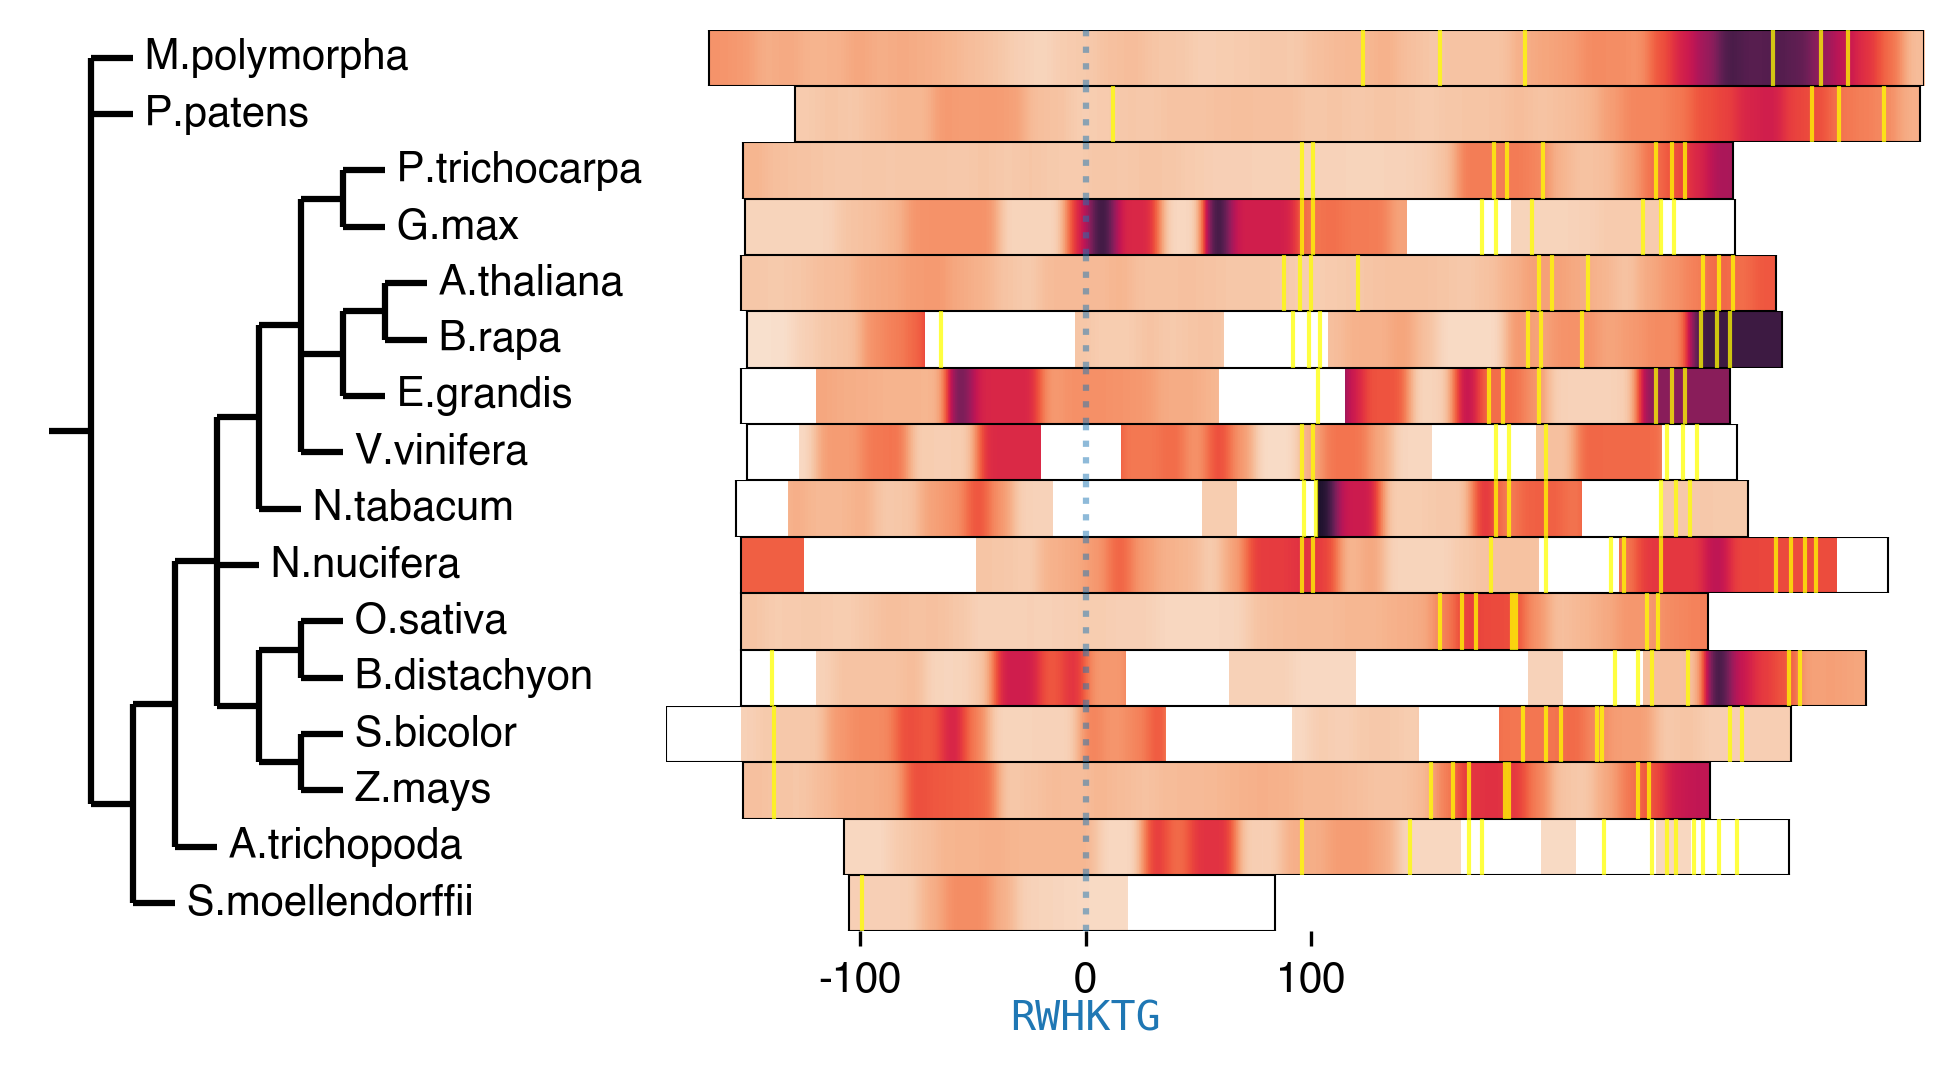

In [85]:
plot_next_to_tree_with_PS(tree)
plt.savefig("../output/figures/conservation/DBD_species_tree.png", bbox_inches='tight')

---
# Using tree from Margot

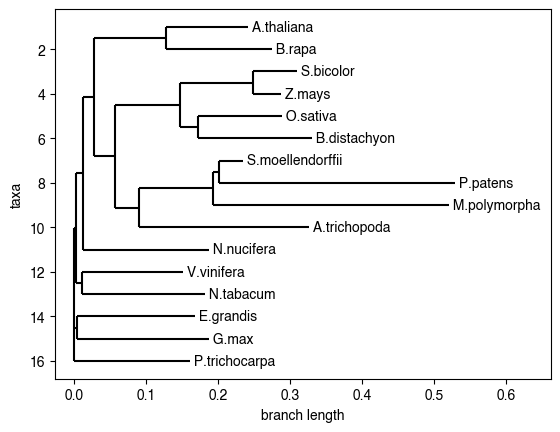

In [86]:
margot_tree = Phylo.read("../data/clustalw.dnd", "newick")
Phylo.draw(margot_tree)

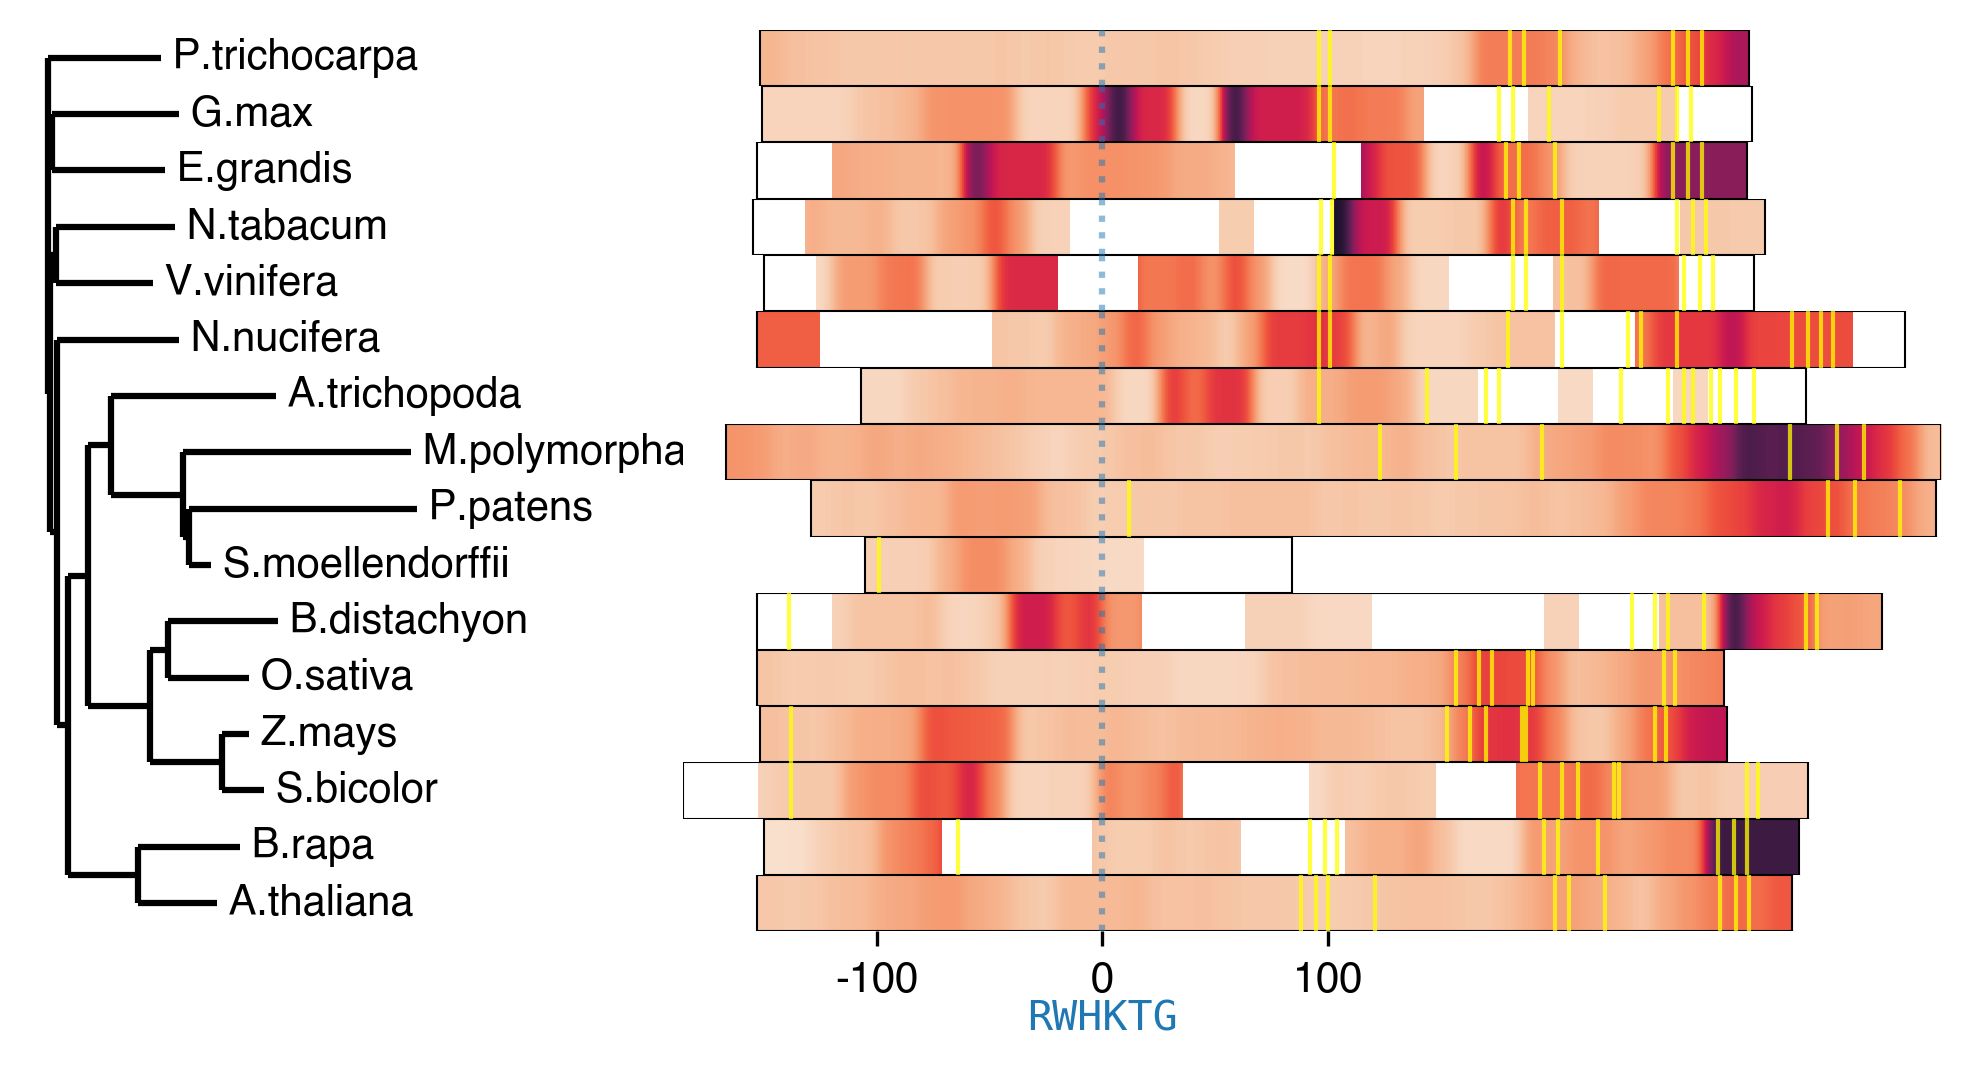

In [87]:
plot_next_to_tree_with_PS(margot_tree)

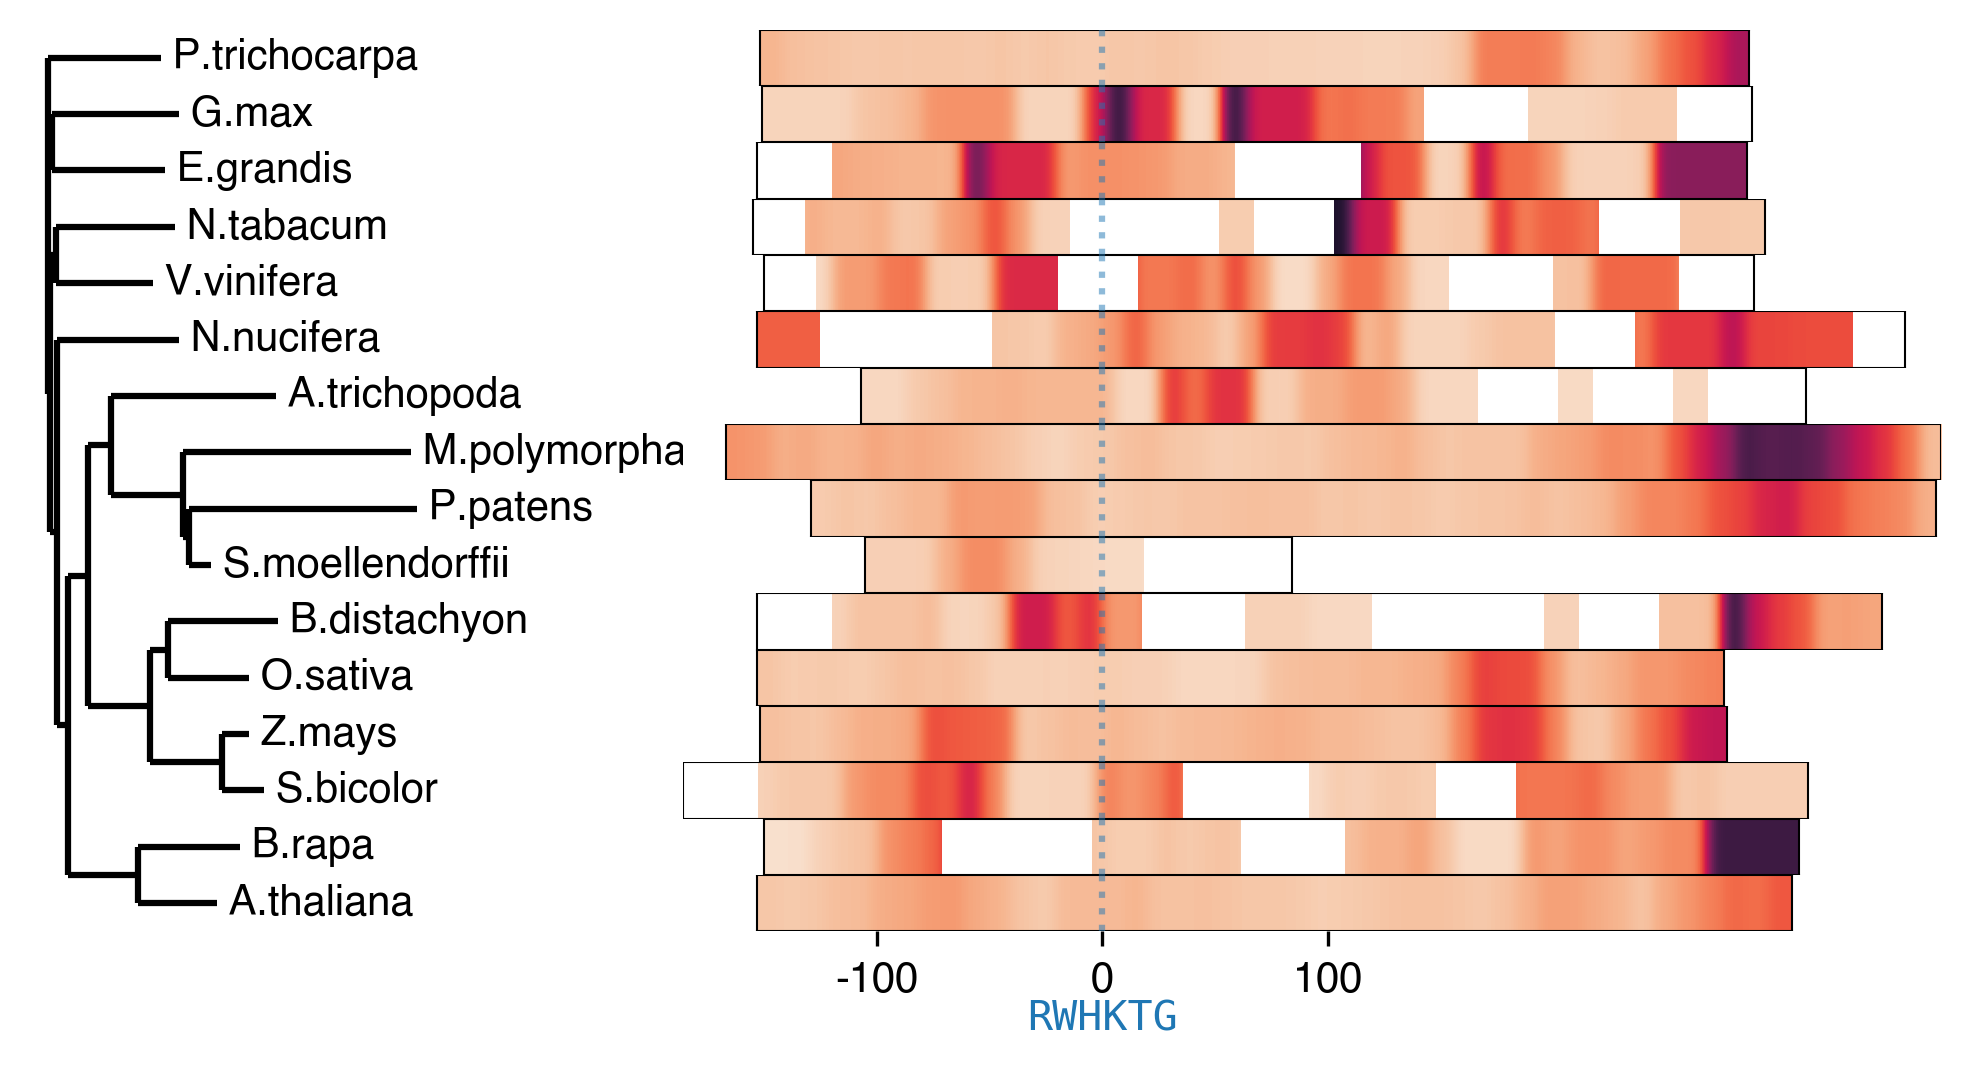

In [88]:
plot_next_to_tree(margot_tree)